# Cài đặt thư viện và đọc dữ liệu

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import norm
from scipy.stats import ks_2samp, chi2_contingency
import gdown
import warnings
warnings.filterwarnings('ignore')

In [5]:
drive_files = {
    'inventory': '1vAMltQY1HzyfYbSaqHmiX7vG3x-0nzgg',
    'products': '1ChaIE-mxZusnsUN3uPQLzrgO8iWFFB_o',
    'promotions': '1gOSK-MYviA_AqWcgC6P8H7wvfwHT-icy',
    'returns': '1MfqBi7Kvo2GEKG8PlERQPIB2NMqIsW5_',
    'sales': '1wymVLHfIkObDNZDbG5OKauIpZF8_7srT',
    'sample_submission': '1_csutoXN2ozsCnM07zFJHwG1bhwn9j5B',
    'web_traffic': '1YwWikoZJyQYEMrcc--CNweJF_wZ-9HF5'
}

dfs = {}

print("Đang tải dữ liệu, vui lòng đợi...")
for name, file_id in drive_files.items():
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    dfs[name] = pd.read_csv(url)
    print(f"Đã tải xong: {name}")

df_inventory = dfs['inventory']
df_products = dfs['products']
df_promotions = dfs['promotions']
df_returns = dfs['returns']
df_sales = dfs['sales']
df_submission = dfs['sample_submission']
df_web_traffic = dfs['web_traffic']

Đang tải dữ liệu, vui lòng đợi...
Đã tải xong: inventory
Đã tải xong: products
Đã tải xong: promotions
Đã tải xong: returns
Đã tải xong: sales
Đã tải xong: sample_submission
Đã tải xong: web_traffic


In [6]:
# 1. Tìm hiểu cấu trúc và tổng quan dữ liệu:
#    - Xem vài dòng đầu: df.head()
#    - Xem thông tin tổng quát (kiểu dữ liệu, số lượng non-null): df.info()
#    - Kích thước dữ liệu: df.shape

# 2. Thống kê mô tả:
#    - Giá trị trung bình, độ lệch chuẩn, min, max, các tứ phân vị cho cột số:

# 3. Kiểm tra và xử lý dữ liệu thiếu (Missing Values):
#    - Xác định số lượng giá trị thiếu: df.isnull().sum()
#    - Quyết định cách xử lý (điền, xóa, ...)

# 4. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicate Values):
#    - Xác định số lượng dòng trùng lặp: df.duplicated().sum()
#    - Xóa các dòng trùng lặp: df.drop_duplicates()

# 5. Phân tích đơn biến (Univariate Analysis):
#    - Đối với biến số: Biểu đồ Histogram, Box plot để xem phân bố, phát hiện ngoại lệ.
#    - Đối với biến định tính: Biểu đồ tần số (Bar plot), đếm giá trị (value_counts()).

# 6. Phân tích đa biến (Bivariate/Multivariate Analysis):
#    - Mối quan hệ giữa hai biến số: Biểu đồ Scatter plot, ma trận tương quan (correlation matrix).
#    - Mối quan hệ giữa biến số và biến định tính: Box plot, Bar plot theo nhóm.
#    - Phân tích Group By để tổng hợp dữ liệu theo các nhóm.

# 7. Phát hiện và xử lý ngoại lệ (Outlier Detection):
#    - Sử dụng Box plot, z-score, IQR để xác định.
#    - Quyết định cách xử lý (loại bỏ, thay thế, giữ lại).

# 8. Chuyển đổi kiểu dữ liệu (Data Type Conversion):
#    - Chuyển đổi các cột sang đúng kiểu dữ liệu mong muốn (ví dụ: object sang datetime, int sang category).

# Inventory

| Cột | Kiểu | Mô tả |
| :------------ | :------------ | :------------ |
| `snapshot_date` | `date` | Ngày chụp (cuối tháng) |
| `product_id` | `int` | FK → products |
| `stock_on_hand` | `int` | Tồn kho cuối tháng |
| `units_received` | `int` | Số lượng nhập kho |
| `units_sold` | `int` | Số lượng bán ra |
| `stockout_days` | `int` | Số ngày hết hàng |
| `days_of_supply` | `float` | Số ngày tồn kho đáp ứng được |
| `fill_rate` | `float` | Tỷ lệ đơn được đáp ứng đủ |
| `stockout_flag` | `int` | Cờ hết hàng |
| `overstock_flag` | `int` | Cờ tồn kho vượt mức |
| `reorder_flag` | `int` | Cờ cần tái đặt hàng |
| `sell_through_rate` | `float` | Tỷ lệ hàng đã bán / tổng sẵn có |
| `product_name` | `string` | Tên sản phẩm |
| `category` | `string` | Danh mục sản phẩm |
| `segment` | `string` | Phân khúc sản phẩm |
| `year` | `int` | Năm |
| `month` | `int` | Tháng |

## 1. Tìm hiểu cấu trúc và tổng quan dữ liệu:

In [7]:
print('5 dòng đầu của df_inventory:')
display(df_inventory.head())

5 dòng đầu của df_inventory:


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5


In [8]:
print('Thông tin tổng quát của df_inventory:')
df_inventory.info()

Thông tin tổng quát của df_inventory:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   snapshot_date      60247 non-null  object 
 1   product_id         60247 non-null  int64  
 2   stock_on_hand      60247 non-null  int64  
 3   units_received     60247 non-null  int64  
 4   units_sold         60247 non-null  int64  
 5   stockout_days      60247 non-null  int64  
 6   days_of_supply     60247 non-null  float64
 7   fill_rate          60247 non-null  float64
 8   stockout_flag      60247 non-null  int64  
 9   overstock_flag     60247 non-null  int64  
 10  reorder_flag       60247 non-null  int64  
 11  sell_through_rate  60247 non-null  float64
 12  product_name       60247 non-null  object 
 13  category           60247 non-null  object 
 14  segment            60247 non-null  object 
 15  year               60247 non-nul

In [9]:
print('Kích thước của df_inventory:')
df_inventory.shape

Kích thước của df_inventory:


(60247, 17)

## 2. Thống kê mô tả:

In [10]:
# Thống kê mô tả cho df_inventory
df_inventory.describe()

,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month
count,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.0,60247.000000,60247.000000,60247.000000
mean,1311.408468,189.298455,18.046807,15.417764,1.160639,912.677576,0.961312,0.673411,0.762561,0.0,0.152275,2017.222799,6.617292
std,673.051769,316.976124,34.080228,28.404379,1.624490,2587.624108,0.054156,0.468969,0.425517,0.0,0.139291,2.972353,3.385629
min,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,0.066700,0.000000,0.000000,0.0,0.000400,2012.000000,1.000000
25%,760.000000,15.000000,2.000000,2.000000,0.000000,96.000000,0.933300,0.000000,1.000000,0.0,0.042100,2015.000000,4.000000
50%,1223.000000,62.000000,6.000000,6.000000,1.000000,240.000000,0.966700,1.000000,1.000000,0.0,0.111100,2017.000000,7.000000
75%,1942.000000,210.000000,19.000000,16.000000,2.000000,683.100000,1.000000,1.000000,1.000000,0.0,0.238100,2020.000000,10.000000
max,2412.000000,2673.000000,817.000000,670.000000,28.000000,68100.000000,1.000000,1.000000,1.000000,0.0,0.853100,2022.000000,12.000000


## 3. Kiểm tra và xử lý dữ liệu thiếu (Missing Values):

In [11]:
# Kiểm tra dữ liệu thiếu
print(df_inventory.isnull().sum())

snapshot_date        0
product_id           0
stock_on_hand        0
units_received       0
units_sold           0
stockout_days        0
days_of_supply       0
fill_rate            0
stockout_flag        0
overstock_flag       0
reorder_flag         0
sell_through_rate    0
product_name         0
category             0
segment              0
year                 0
month                0
dtype: int64


## 4. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicate Values):

In [12]:
# Kiểm tra dữ liệu trùng lặp
print(df_inventory.duplicated().sum())

0


## 5. Phân tích đơn biến (Univariate Analysis):

### Phân tích đơn biến cho các biến định lượng

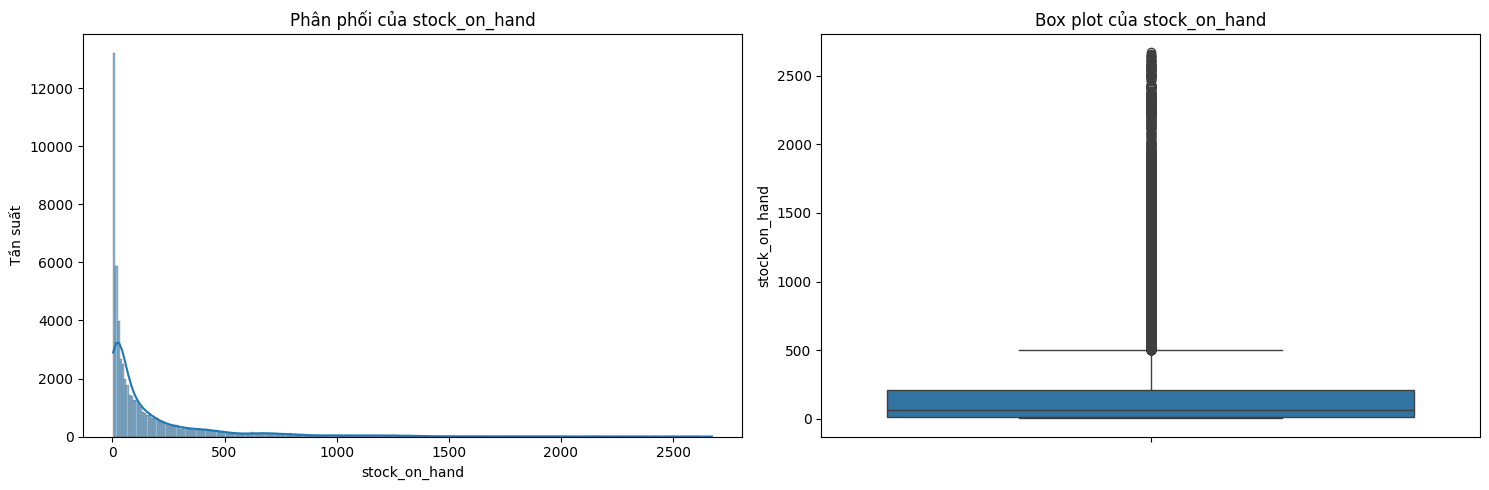

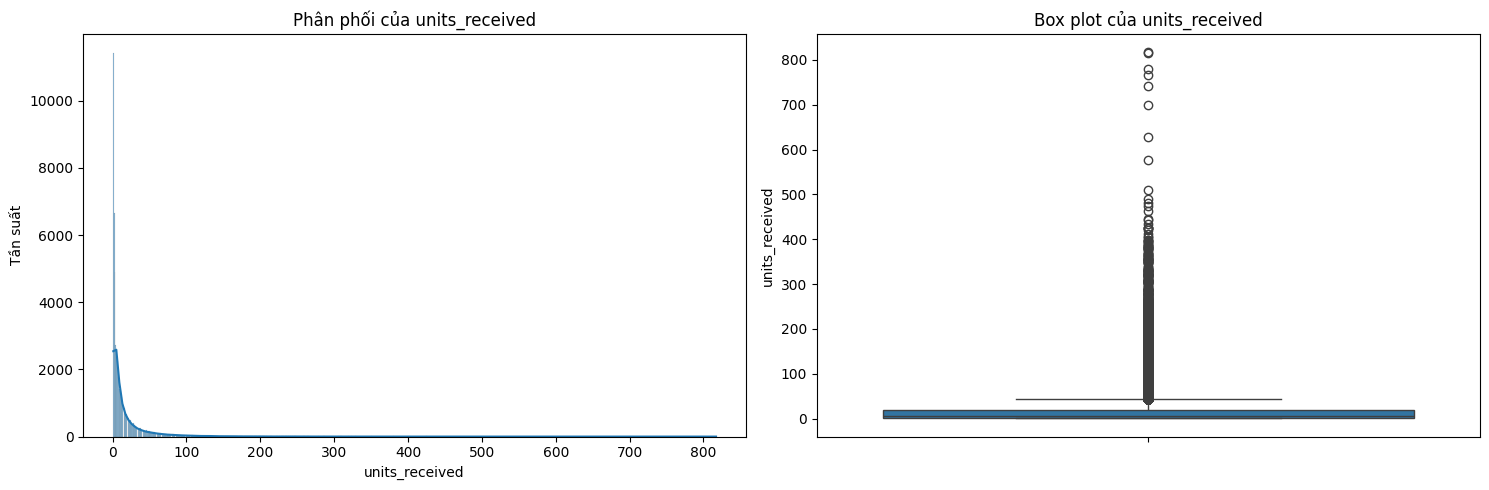

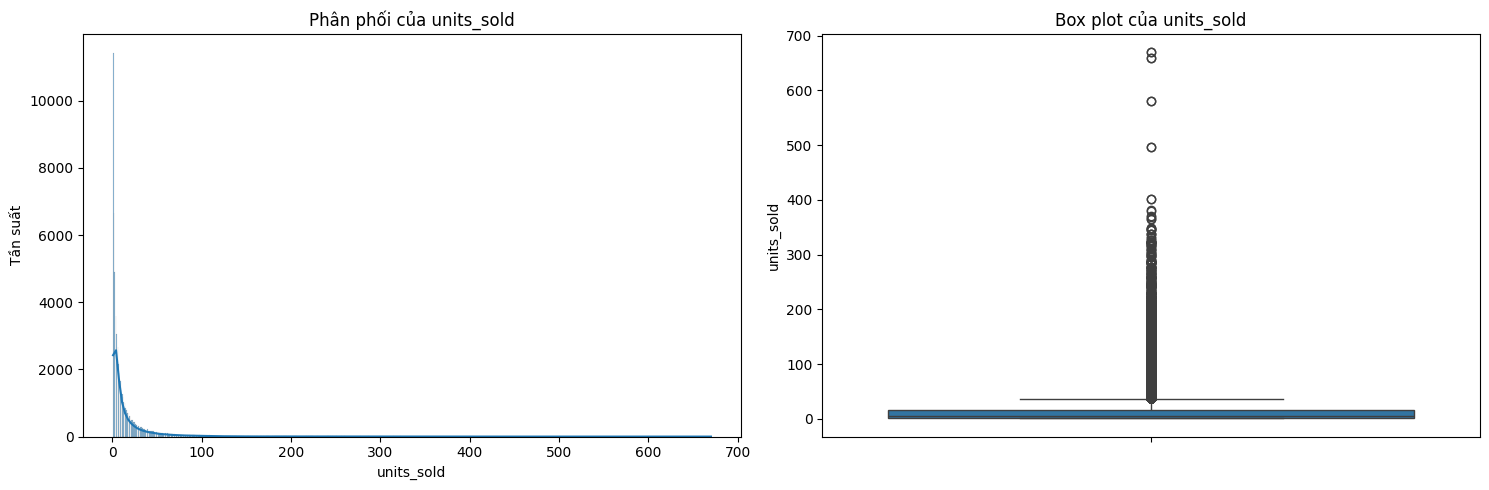

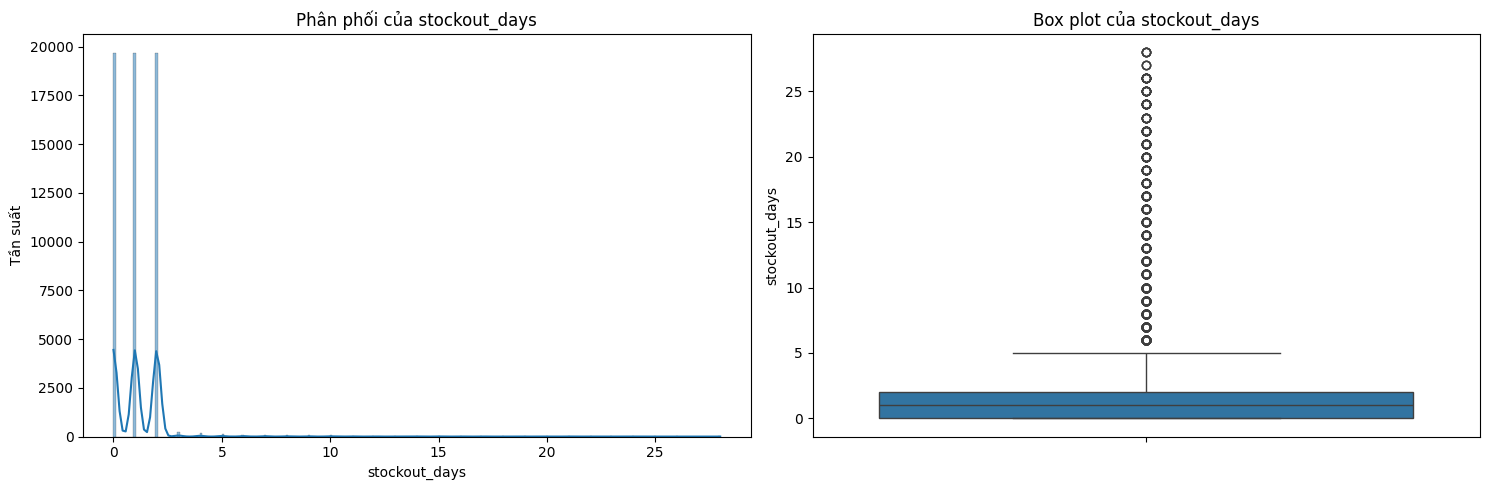

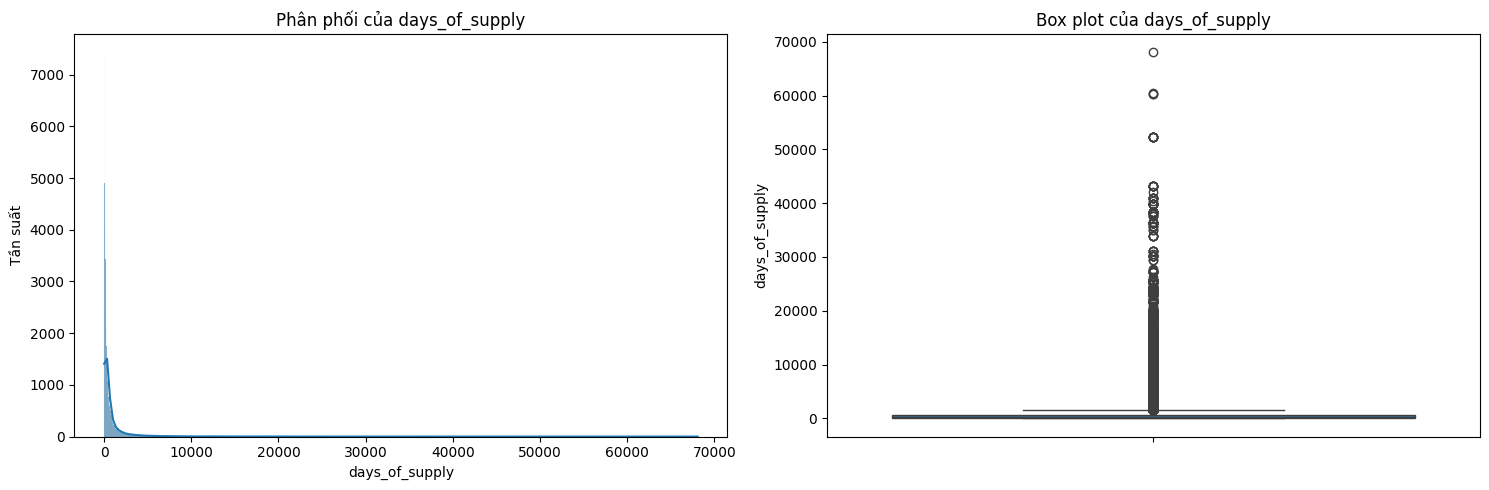

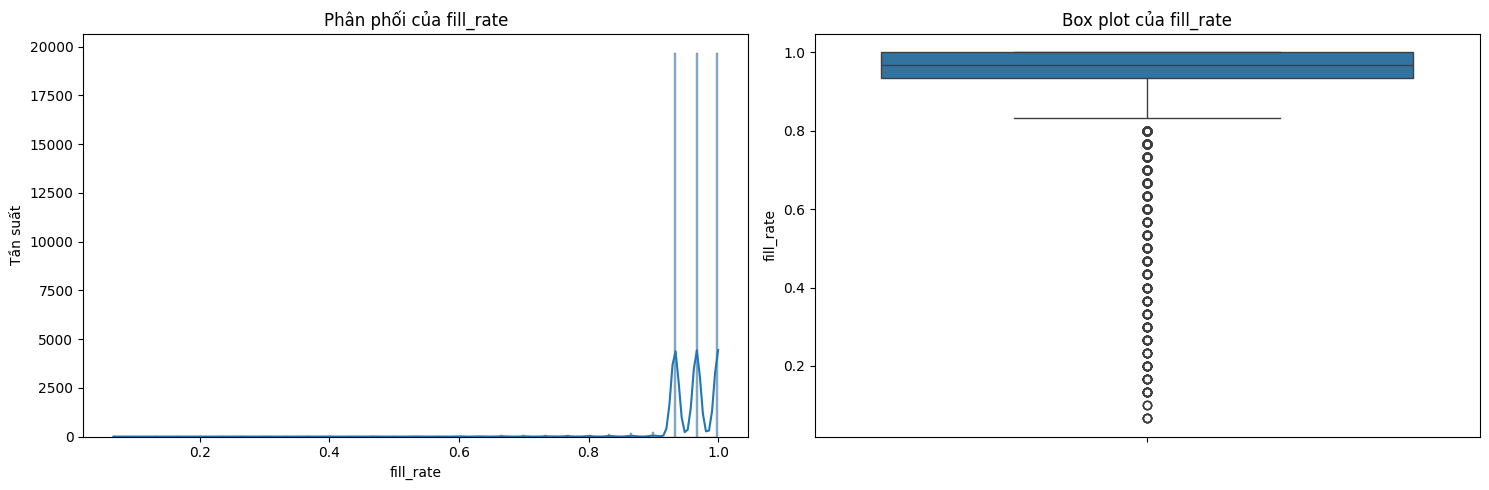

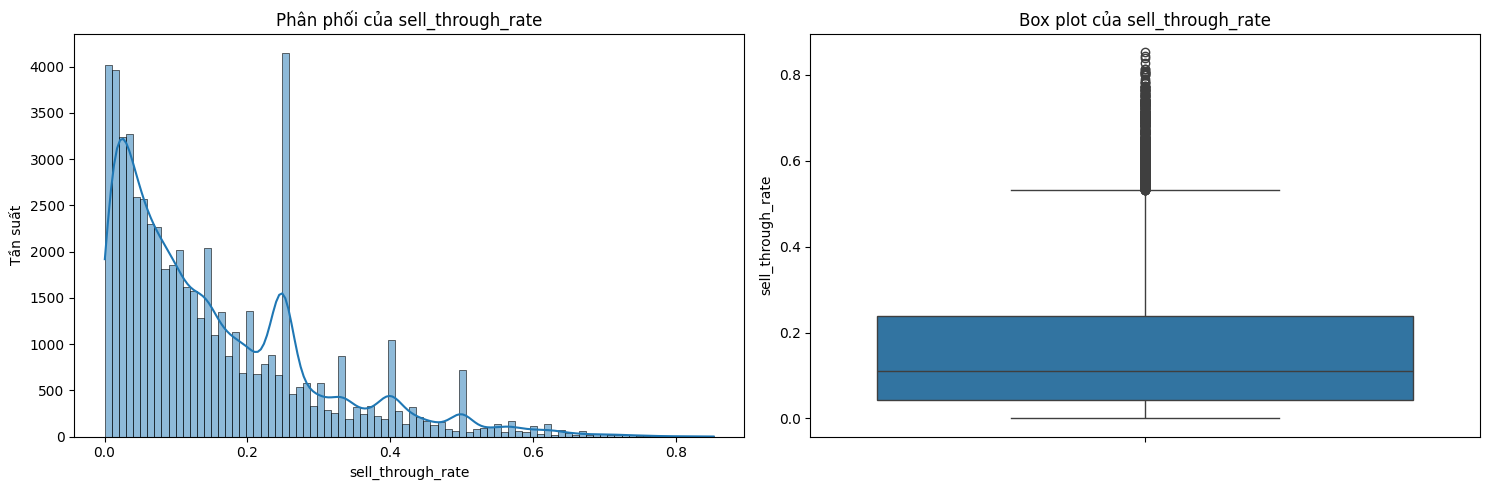

In [13]:
# Lấy danh sách các cột số để phân tích
numerical_cols = df_inventory.select_dtypes(include=np.number).columns.tolist()

# Loại bỏ các cột ID, cờ (flags) và năm/tháng, tập trung vào các biến liên tục
numerical_cols = [col for col in numerical_cols if col not in ['product_id', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'year', 'month']]

for col in numerical_cols:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_inventory[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_inventory[col])
    plt.title(f'Box plot của {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Phân tích đơn biến cho các biến định tính

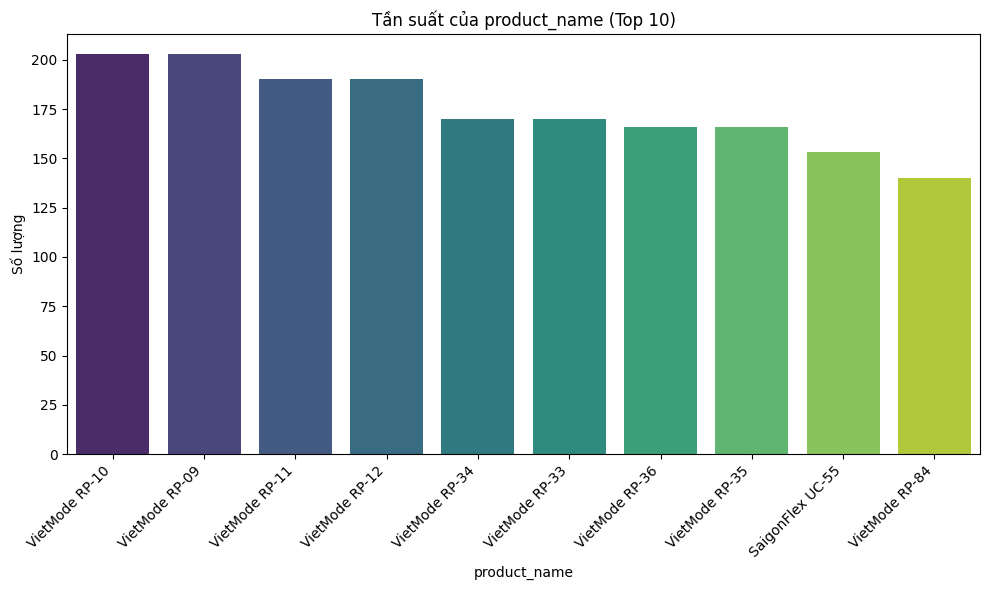

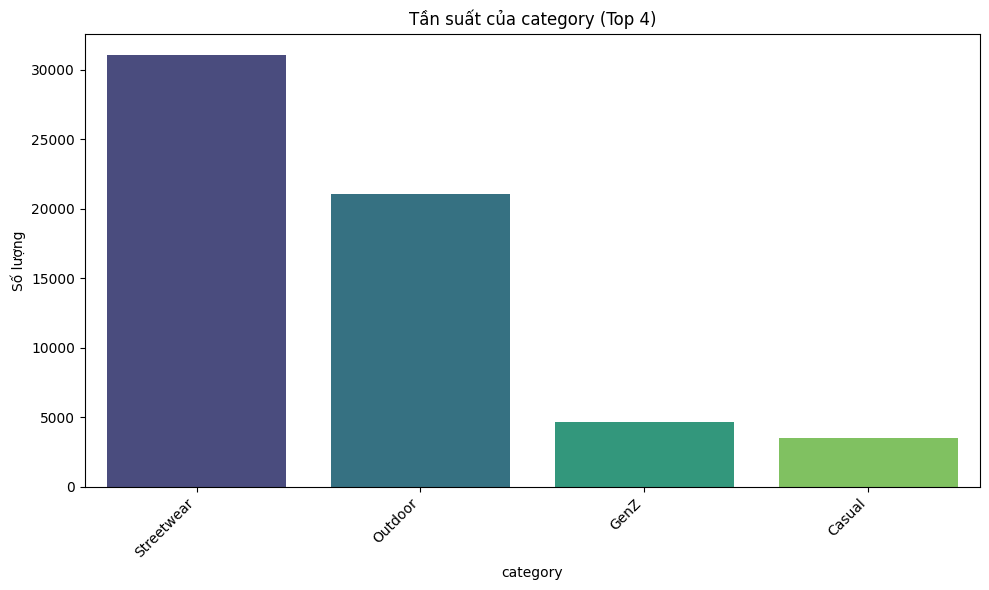

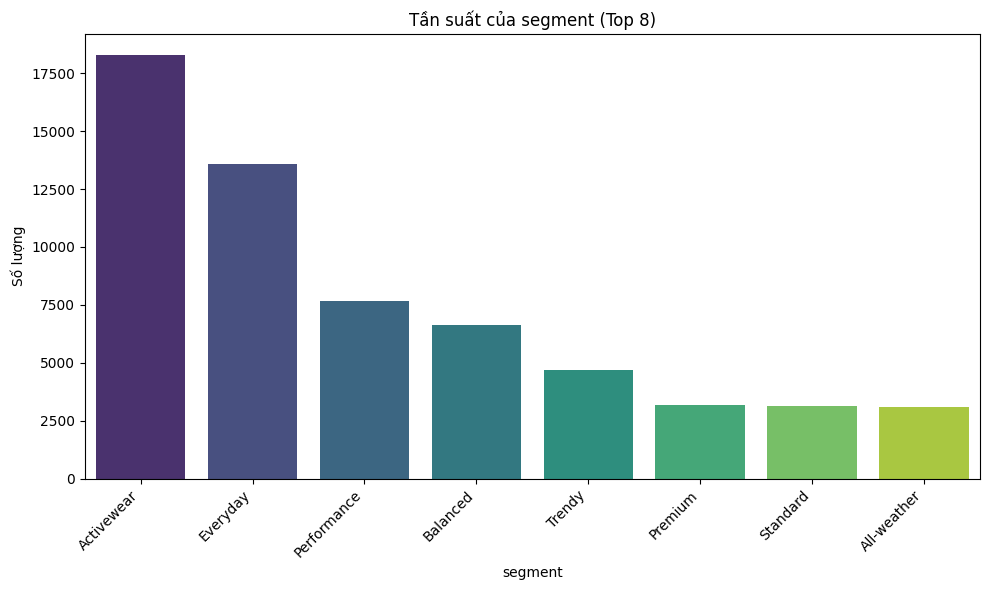

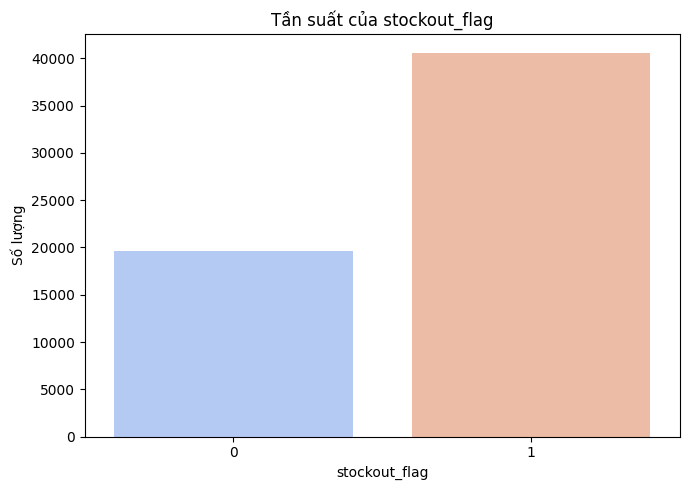

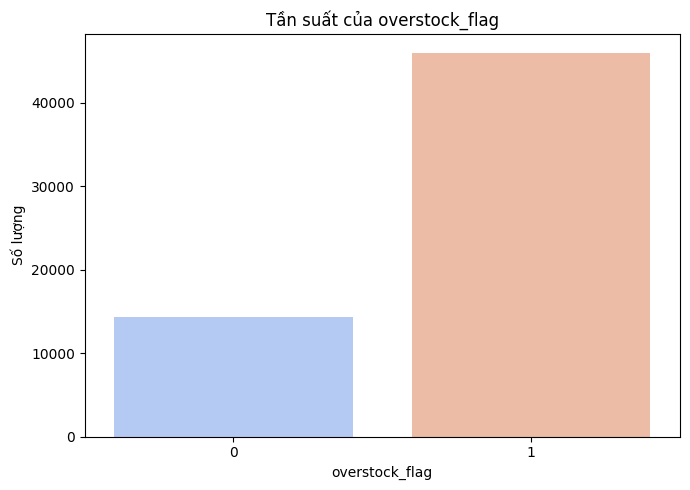

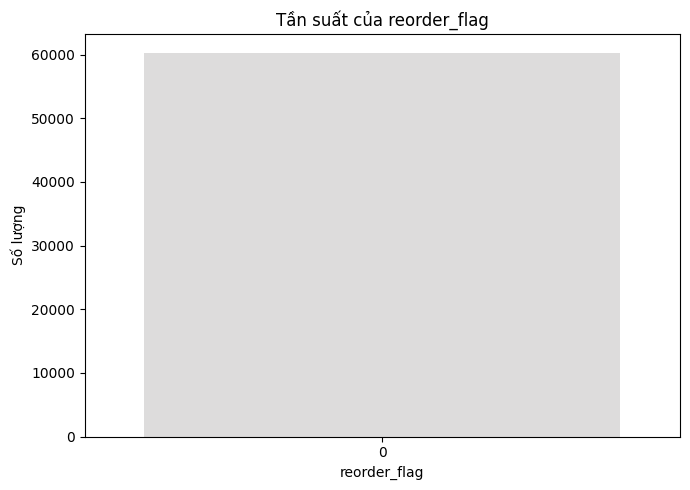

In [14]:
# Lấy danh sách các cột định tính (object)
categorical_cols = df_inventory.select_dtypes(include='object').columns.tolist()

# Loại bỏ 'snapshot_date' vì sẽ xử lý riêng, cần chuyển đổi sang datetime
categorical_cols = [col for col in categorical_cols if col not in ['snapshot_date']]

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    # Sử dụng value_counts() và vẽ bar plot
    top_n = df_inventory[col].value_counts().nlargest(10) # Lấy 10 giá trị hàng đầu
    sns.barplot(x=top_n.index, y=top_n.values, palette='viridis')
    plt.title(f'Tần suất của {col} (Top {len(top_n)})')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Phân tích các cột cờ (binary flags)
binary_flags = ['stockout_flag', 'overstock_flag', 'reorder_flag']
for col in binary_flags:
    plt.figure(figsize=(7, 5))
    sns.countplot(x=df_inventory[col], palette='coolwarm')
    plt.title(f'Tần suất của {col}')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.tight_layout()
    plt.show()

## 6. Phân tích đa biến (Bivariate/Multivariate Analysis):

### Ma trận tương quan giữa các biến số

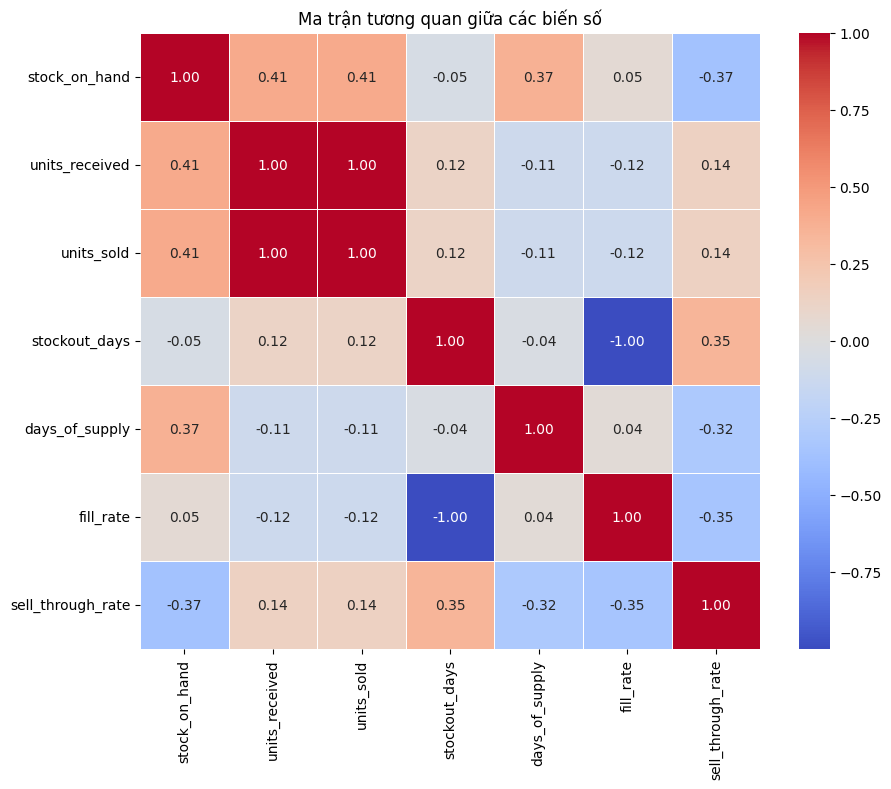

In [15]:
# Chọn các cột số liên quan để tính ma trận tương quan
correlation_cols = ['stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'sell_through_rate']

# Tính ma trận tương quan
corr_matrix = df_inventory[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

### Mối quan hệ giữa 'units_sold' và các biến số khác

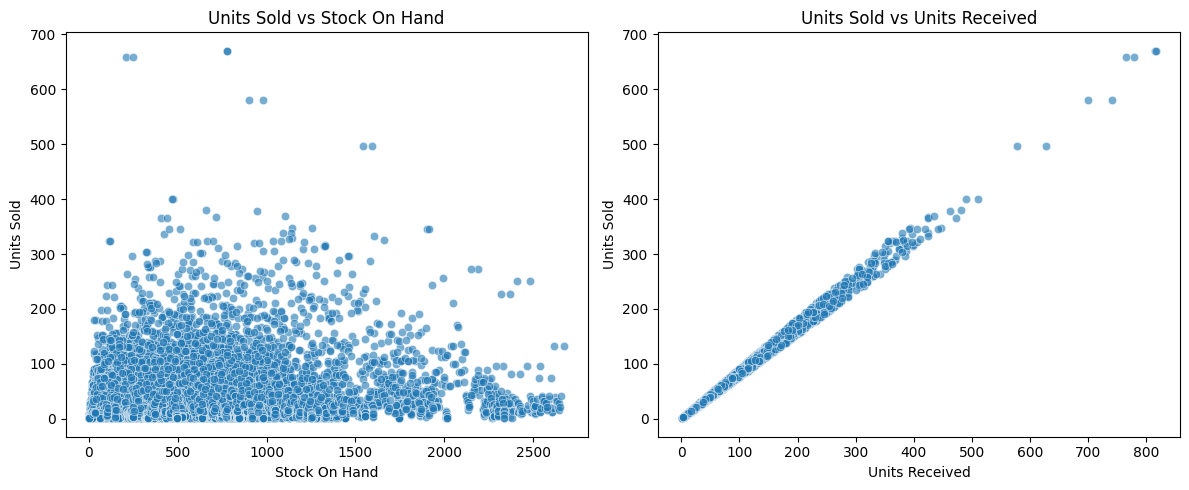

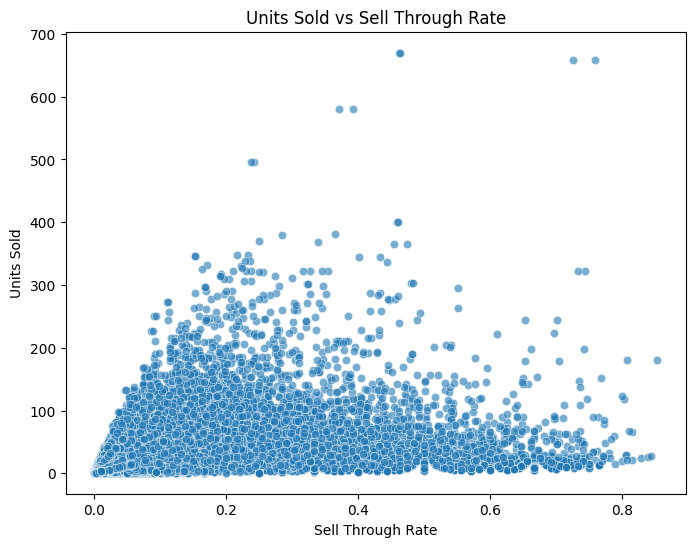

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='stock_on_hand', y='units_sold', data=df_inventory, alpha=0.6)
plt.title('Units Sold vs Stock On Hand')
plt.xlabel('Stock On Hand')
plt.ylabel('Units Sold')

plt.subplot(1, 2, 2)
sns.scatterplot(x='units_received', y='units_sold', data=df_inventory, alpha=0.6)
plt.title('Units Sold vs Units Received')
plt.xlabel('Units Received')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='sell_through_rate', y='units_sold', data=df_inventory, alpha=0.6)
plt.title('Units Sold vs Sell Through Rate')
plt.xlabel('Sell Through Rate')
plt.ylabel('Units Sold')
plt.show()

### Mối quan hệ giữa biến số và biến định tính

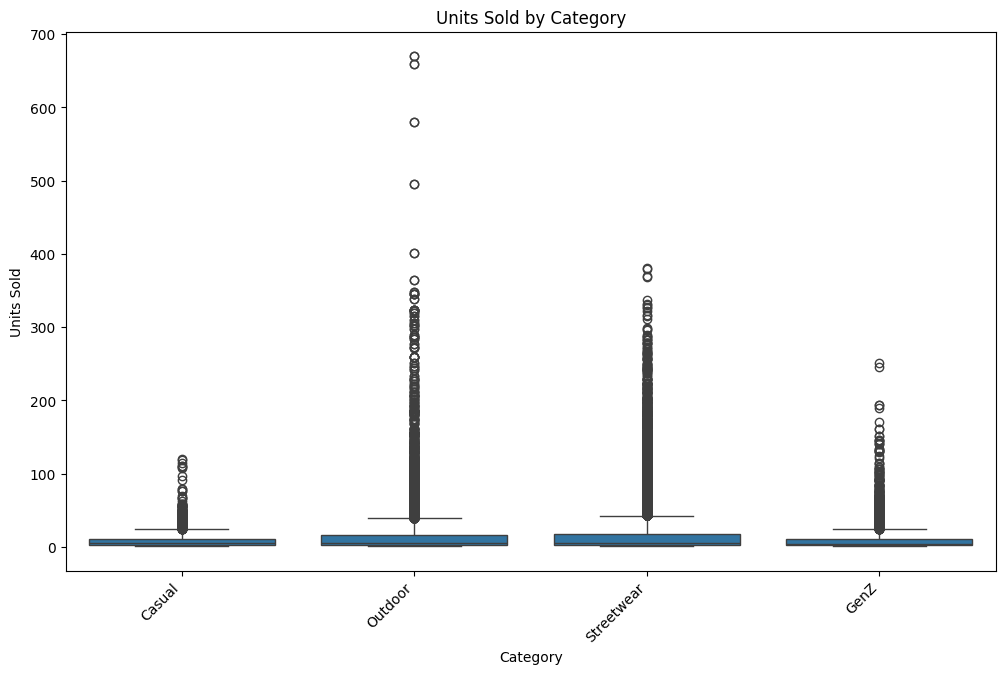

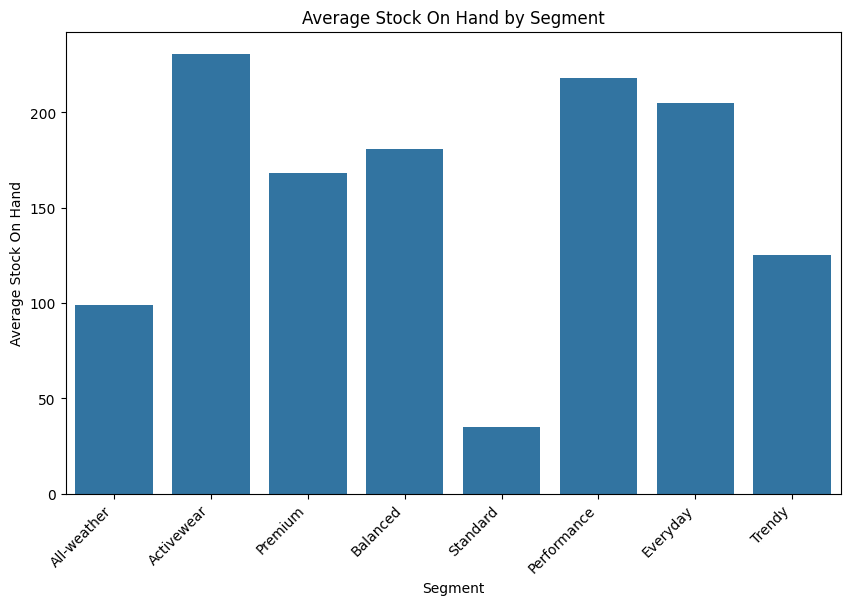

In [17]:
# Box plot của Units Sold theo Category
plt.figure(figsize=(12, 7))
sns.boxplot(x='category', y='units_sold', data=df_inventory)
plt.title('Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.show()

# Bar plot của Stock On Hand trung bình theo Segment
plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='stock_on_hand', data=df_inventory, estimator=np.mean, ci=None)
plt.title('Average Stock On Hand by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Stock On Hand')
plt.xticks(rotation=45, ha='right')
plt.show()

## 7. Phát hiện và xử lý ngoại lệ (Outlier Detection):

Phát hiện ngoại lệ sử dụng phương pháp IQR:

Cột 'stock_on_hand':
  Q1: 15.00, Q3: 210.00, IQR: 195.00
  Ngưỡng dưới (Lower Bound): -277.50
  Ngưỡng trên (Upper Bound): 502.50
  Số lượng ngoại lệ: 6432
  Phần trăm ngoại lệ: 10.68%


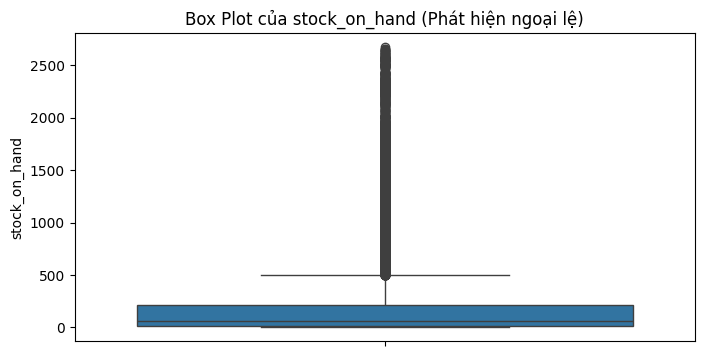


Cột 'units_received':
  Q1: 2.00, Q3: 19.00, IQR: 17.00
  Ngưỡng dưới (Lower Bound): -23.50
  Ngưỡng trên (Upper Bound): 44.50
  Số lượng ngoại lệ: 6392
  Phần trăm ngoại lệ: 10.61%


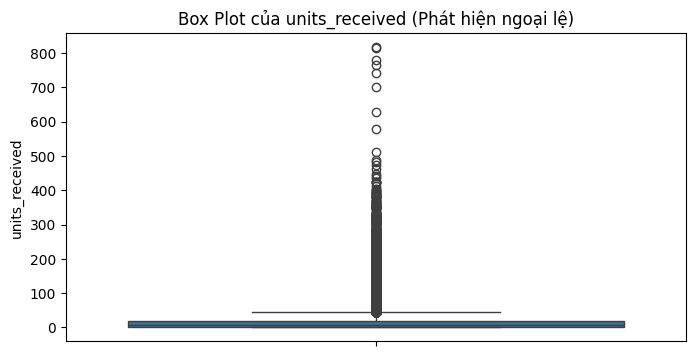


Cột 'units_sold':
  Q1: 2.00, Q3: 16.00, IQR: 14.00
  Ngưỡng dưới (Lower Bound): -19.00
  Ngưỡng trên (Upper Bound): 37.00
  Số lượng ngoại lệ: 6388
  Phần trăm ngoại lệ: 10.60%


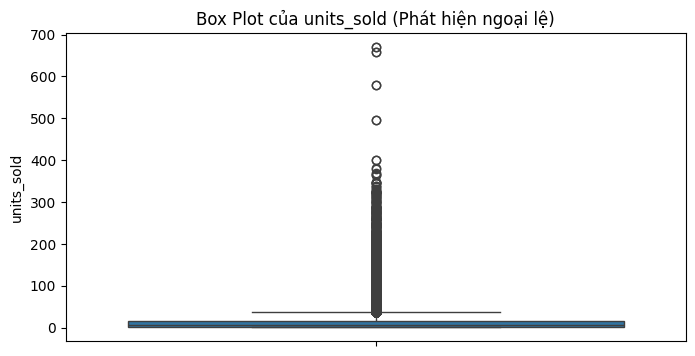


Cột 'stockout_days':
  Q1: 0.00, Q3: 2.00, IQR: 2.00
  Ngưỡng dưới (Lower Bound): -3.00
  Ngưỡng trên (Upper Bound): 5.00
  Số lượng ngoại lệ: 724
  Phần trăm ngoại lệ: 1.20%


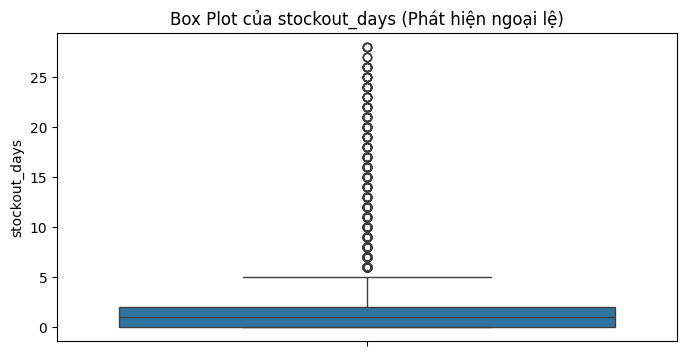


Cột 'days_of_supply':
  Q1: 96.00, Q3: 683.10, IQR: 587.10
  Ngưỡng dưới (Lower Bound): -784.65
  Ngưỡng trên (Upper Bound): 1563.75
  Số lượng ngoại lệ: 7455
  Phần trăm ngoại lệ: 12.37%


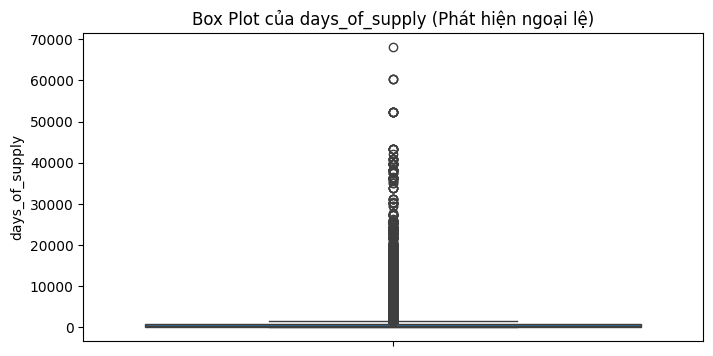


Cột 'fill_rate':
  Q1: 0.93, Q3: 1.00, IQR: 0.07
  Ngưỡng dưới (Lower Bound): 0.83
  Ngưỡng trên (Upper Bound): 1.10
  Số lượng ngoại lệ: 724
  Phần trăm ngoại lệ: 1.20%


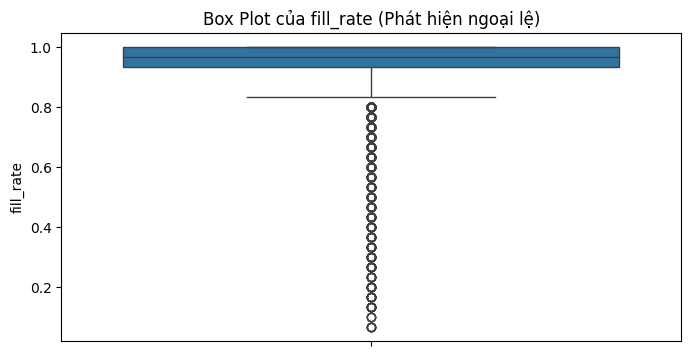


Cột 'sell_through_rate':
  Q1: 0.04, Q3: 0.24, IQR: 0.20
  Ngưỡng dưới (Lower Bound): -0.25
  Ngưỡng trên (Upper Bound): 0.53
  Số lượng ngoại lệ: 1284
  Phần trăm ngoại lệ: 2.13%


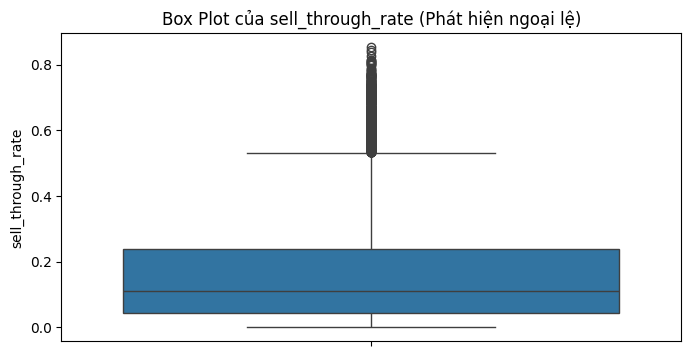

In [18]:
# Lấy danh sách các cột số để phân tích ngoại lệ
# Loại bỏ các cột ID, cờ (flags) và năm/tháng, tập trung vào các biến liên tục
numerical_cols_outliers = [col for col in df_inventory.select_dtypes(include=np.number).columns.tolist() if col not in ['product_id', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'year', 'month']]

print("Phát hiện ngoại lệ sử dụng phương pháp IQR:")
for col in numerical_cols_outliers:
    Q1 = df_inventory[col].quantile(0.25)
    Q3 = df_inventory[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_inventory[(df_inventory[col] < lower_bound) | (df_inventory[col] > upper_bound)]

    print(f"\nCột '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
    print(f"  Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
    print(f"  Số lượng ngoại lệ: {len(outliers)}")
    if not outliers.empty:
        print(f"  Phần trăm ngoại lệ: {len(outliers) / len(df_inventory) * 100:.2f}%")
        # Hiển thị vài dòng dữ liệu ngoại lệ nếu có
        # print("  Dữ liệu ngoại lệ (5 dòng đầu):\n", outliers[[col]].head())

    # Trực quan hóa ngoại lệ bằng Box Plot
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df_inventory[col])
    plt.title(f'Box Plot của {col} (Phát hiện ngoại lệ)')
    plt.ylabel(col)
    plt.show()

## 8. Chuyển đổi kiểu dữ liệu (Data Type Conversion):

In [19]:
# Chuyển đổi cột 'snapshot_date' sang kiểu datetime
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

# Kiểm tra lại thông tin tổng quát để xác nhận kiểu dữ liệu đã thay đổi
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[ns]
 1   product_id         60247 non-null  int64         
 2   stock_on_hand      60247 non-null  int64         
 3   units_received     60247 non-null  int64         
 4   units_sold         60247 non-null  int64         
 5   stockout_days      60247 non-null  int64         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int64         
 9   overstock_flag     60247 non-null  int64         
 10  reorder_flag       60247 non-null  int64         
 11  sell_through_rate  60247 non-null  float64       
 12  product_name       60247 non-null  object        
 13  category           60247 non-null  object        
 14  segmen

# Products

| Cột | Kiểu | Mô tả |
| :------------ | :------------ | :------------ |
| `product_id` | `int` | Khoá chính |
| `product_name` | `str` | Tên sản phẩm |
| `category` | `str` | Danh mục sản phẩm |
| `segment` | `str` | Phân khúc thị trường |
| `size` | `str` | Kích cỡ (S/M/L/XL) |
| `color` | `str` | Nhãn màu sản phẩm |
| `price` | `float` | Giá bán lẻ |
| `cogs` | `float` | Giá vốn hàng bán (< price) |

## 1. Tìm hiểu cấu trúc và tổng quan dữ liệu:

In [20]:
print('5 dòng đầu của df_products:')
display(df_products.head())

5 dòng đầu của df_products:


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


In [21]:
print('Thông tin tổng quát của df_products:')
df_products.info()

Thông tin tổng quát của df_products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [22]:
print('Kích thước của df_products:')
df_products.shape

Kích thước của df_products:


(2412, 8)

## 2. Thống kê mô tả:

In [23]:
# Thống kê mô tả cho df_products
df_products.describe()

,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


## 3. Kiểm tra và xử lý dữ liệu thiếu (Missing Values):

In [24]:
# Kiểm tra dữ liệu thiếu
print(df_products.isnull().sum())

product_id      0
product_name    0
category        0
segment         0
size            0
color           0
price           0
cogs            0
dtype: int64


## 4. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicate Values):

In [25]:
# Kiểm tra dữ liệu trùng lặp
print(df_products.duplicated().sum())

0


## 5. Phân tích đơn biến (Univariate Analysis):

### Phân tích đơn biến cho các biến định lượng

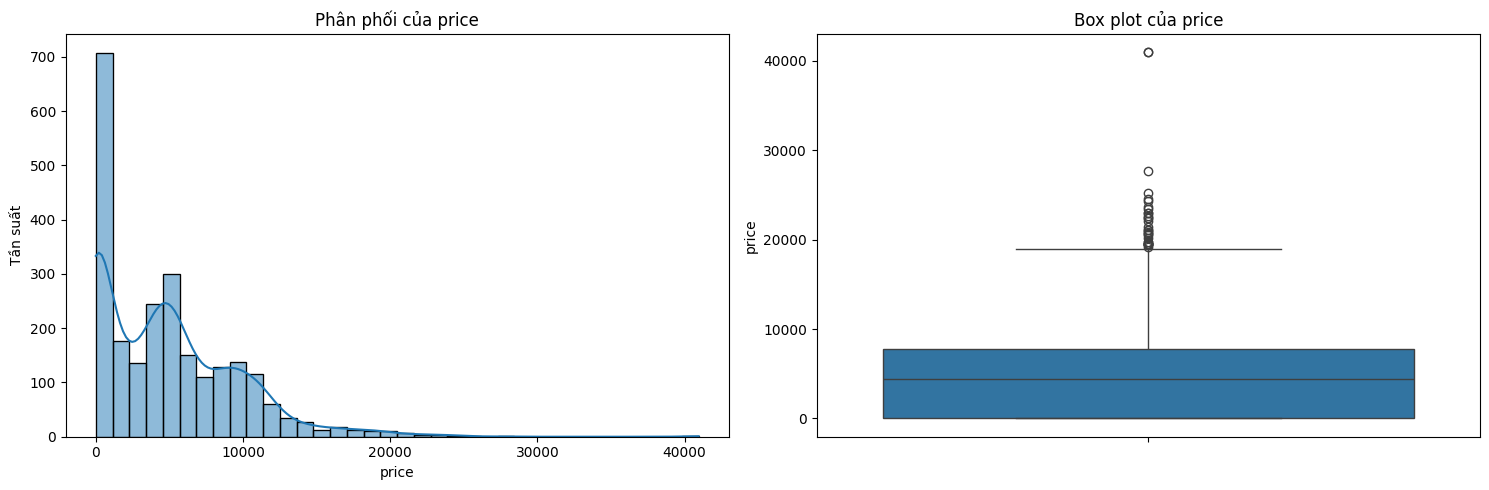

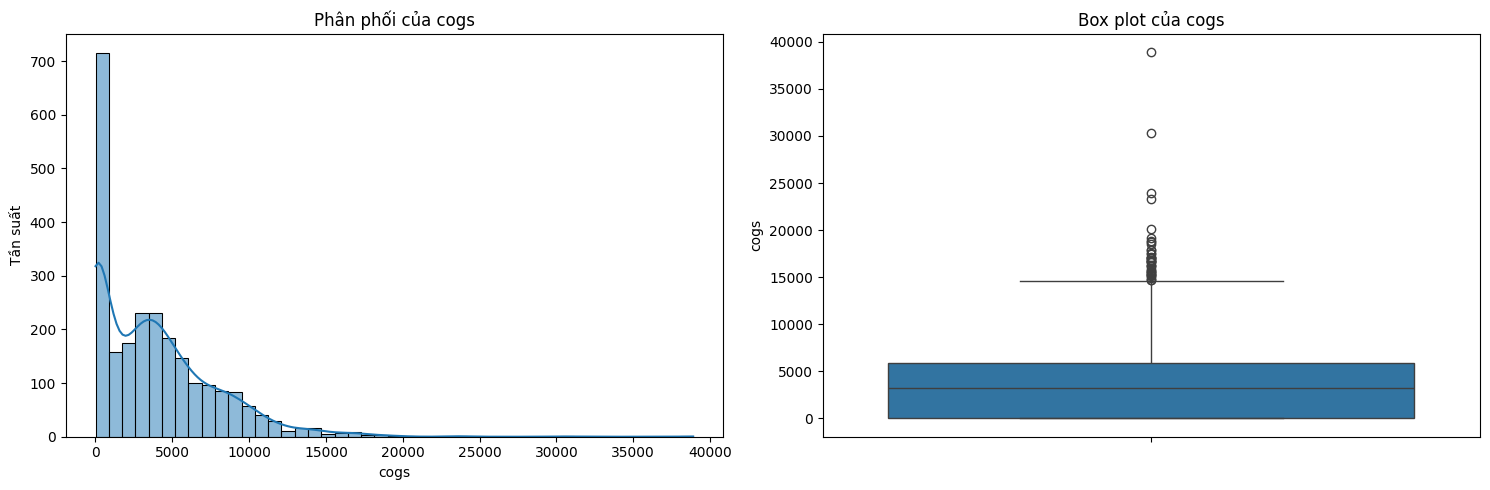

In [26]:
# Lấy danh sách các cột số để phân tích
numerical_cols_products = df_products.select_dtypes(include=np.number).columns.tolist()

# Loại bỏ cột 'product_id' vì đây là định danh
numerical_cols_products = [col for col in numerical_cols_products if col not in ['product_id']]

for col in numerical_cols_products:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_products[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_products[col])
    plt.title(f'Box plot của {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Phân tích đơn biến cho các biến định tính

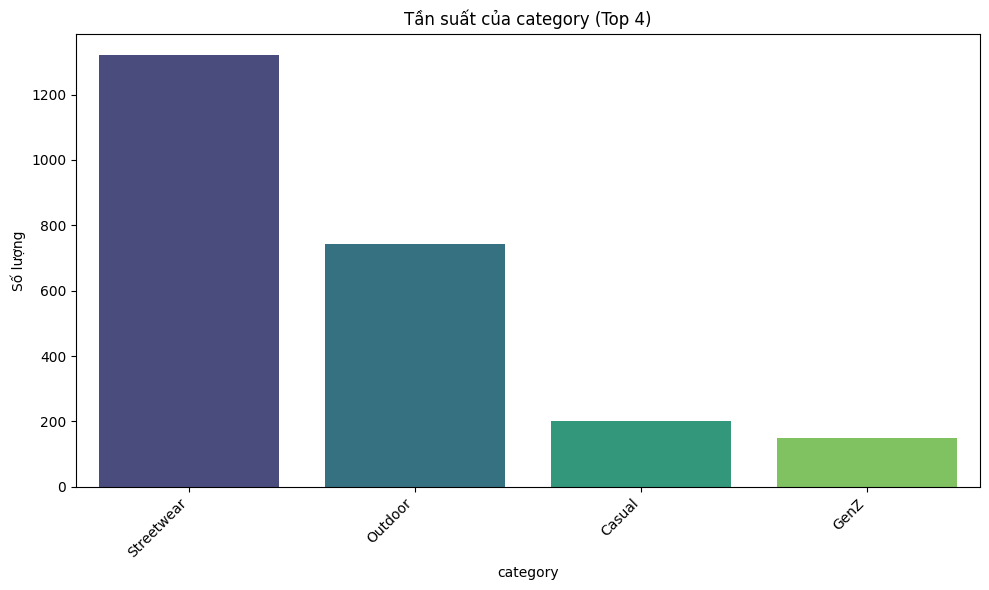

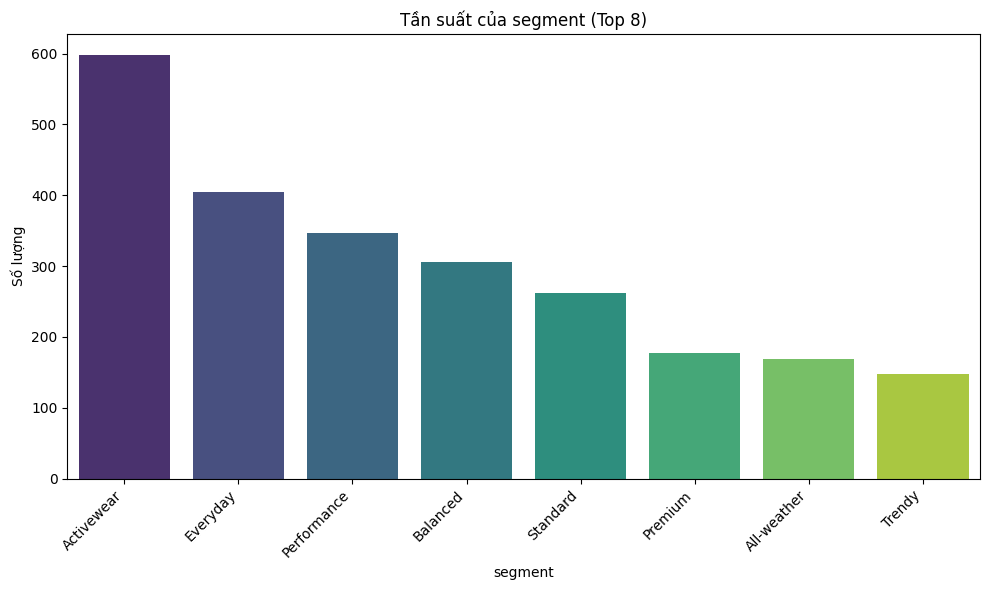

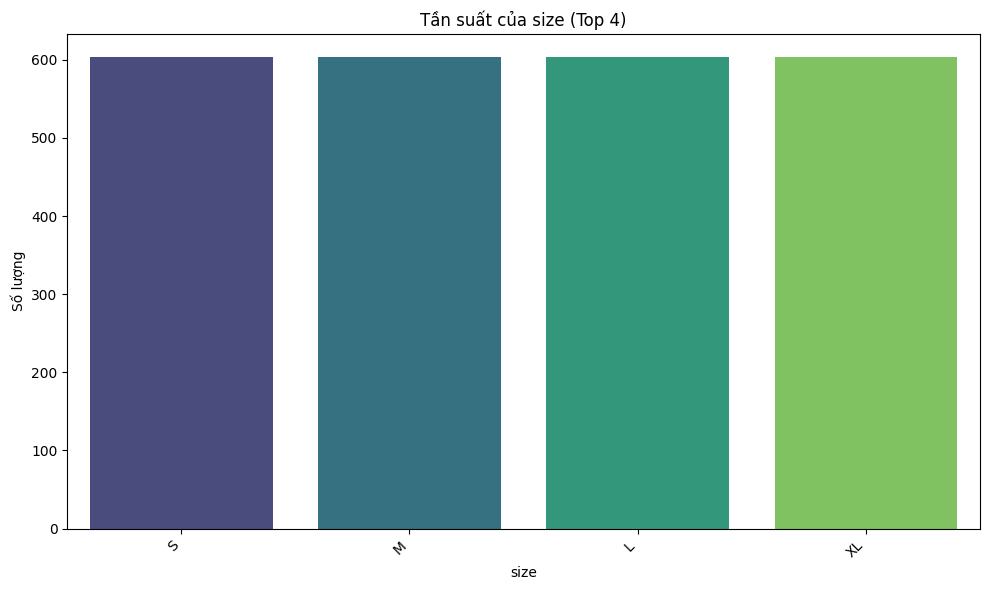

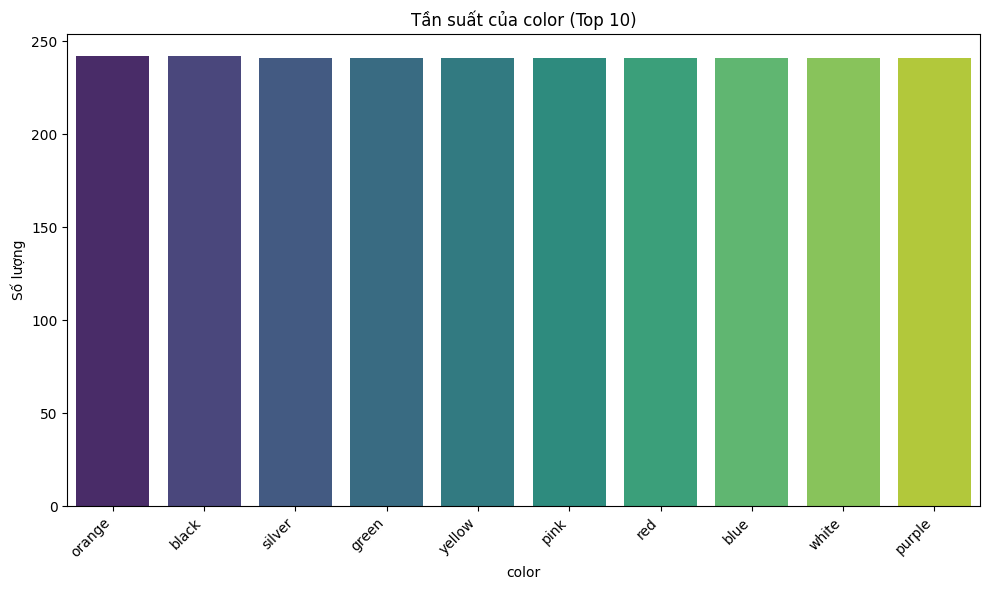

In [27]:
# Lấy danh sách các cột định tính (object)
categorical_cols_products = df_products.select_dtypes(include='object').columns.tolist()

# Loại bỏ 'product_name' vì có quá nhiều giá trị duy nhất
categorical_cols_products = [col for col in categorical_cols_products if col not in ['product_name']]

for col in categorical_cols_products:
    plt.figure(figsize=(10, 6))
    # Sử dụng value_counts() và vẽ bar plot
    top_n = df_products[col].value_counts().nlargest(10) # Lấy 10 giá trị hàng đầu
    sns.barplot(x=top_n.index, y=top_n.values, palette='viridis')
    plt.title(f'Tần suất của {col} (Top {len(top_n)})')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 6. Phân tích đa biến (Bivariate/Multivariate Analysis):

### Ma trận tương quan giữa các biến số

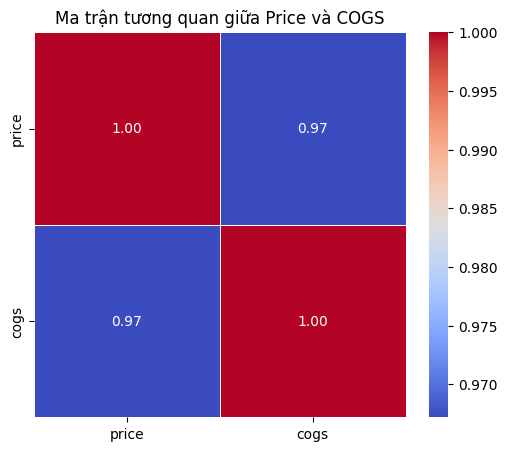

In [28]:
# Chọn các cột số liên quan để tính ma trận tương quan
correlation_cols_products = ['price', 'cogs']

# Tính ma trận tương quan
corr_matrix_products = df_products[correlation_cols_products].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix_products, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Ma trận tương quan giữa Price và COGS')
plt.show()

### Mối quan hệ giữa Price/COGS và các biến định tính

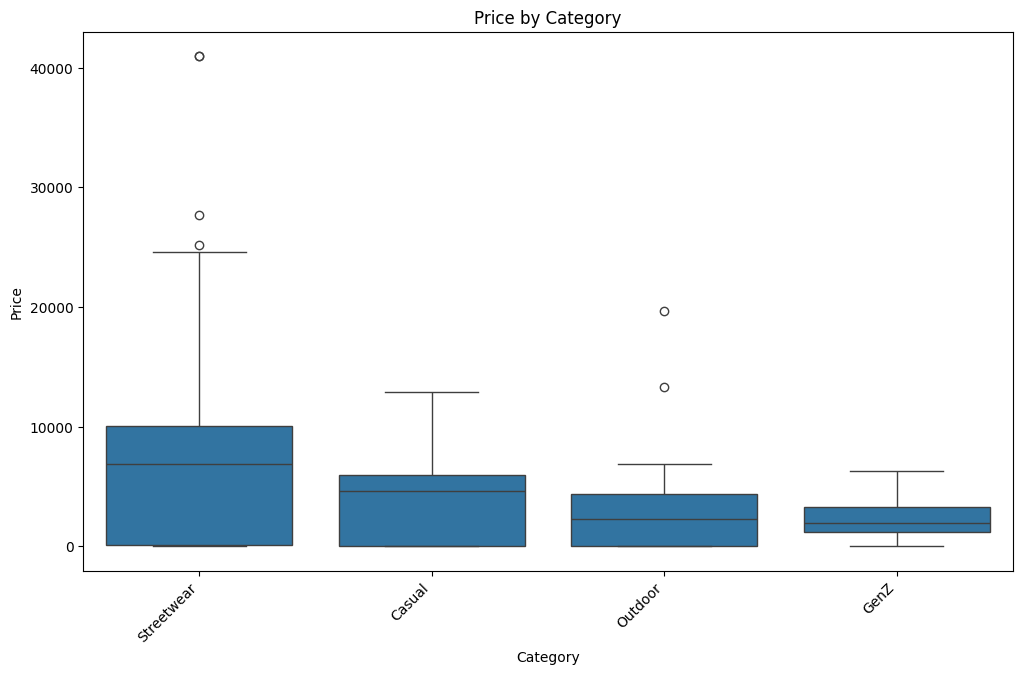

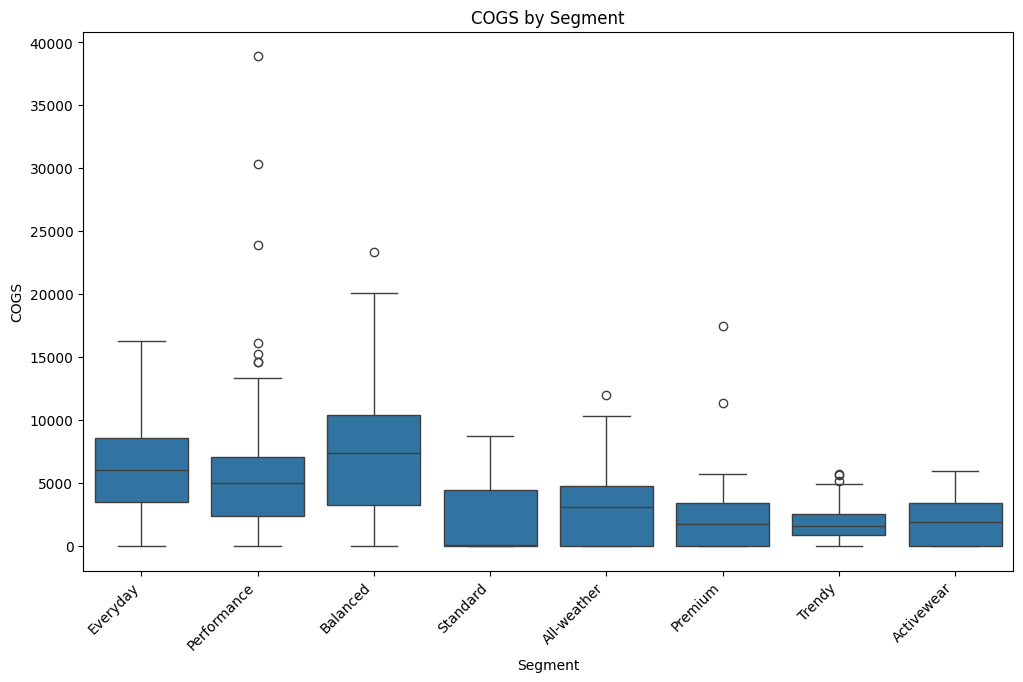

In [29]:
# Box plot của Price theo Category
plt.figure(figsize=(12, 7))
sns.boxplot(x='category', y='price', data=df_products)
plt.title('Price by Category')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.show()

# Box plot của COGS theo Segment
plt.figure(figsize=(12, 7))
sns.boxplot(x='segment', y='cogs', data=df_products)
plt.title('COGS by Segment')
plt.xlabel('Segment')
plt.ylabel('COGS')
plt.xticks(rotation=45, ha='right')
plt.show()

## 7. Phát hiện và xử lý ngoại lệ (Outlier Detection):

Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_products:

Cột 'price':
  Q1: 59.44, Q3: 7720.51, IQR: 7661.07
  Ngưỡng dưới (Lower Bound): -11432.16
  Ngưỡng trên (Upper Bound): 19212.12
  Số lượng ngoại lệ: 31
  Phần trăm ngoại lệ: 1.29%


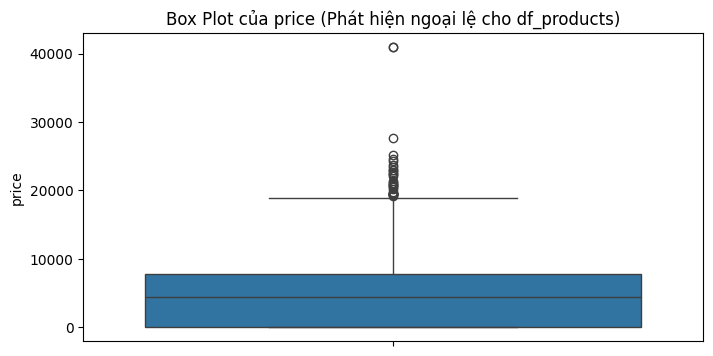


Cột 'cogs':
  Q1: 35.07, Q3: 5864.92, IQR: 5829.85
  Ngưỡng dưới (Lower Bound): -8709.71
  Ngưỡng trên (Upper Bound): 14609.69
  Số lượng ngoại lệ: 37
  Phần trăm ngoại lệ: 1.53%


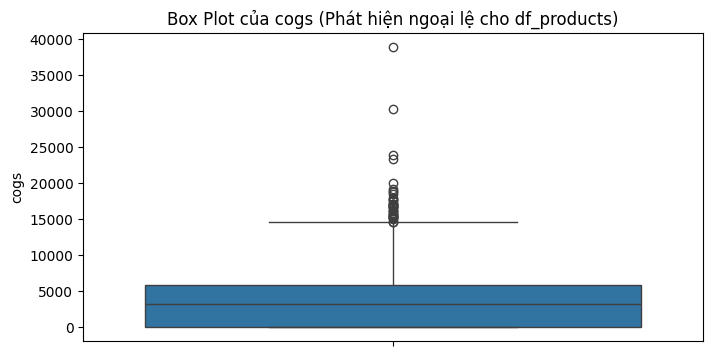

In [30]:
# Lấy danh sách các cột số để phân tích ngoại lệ
# Loại bỏ 'product_id' vì đây là định danh
numerical_cols_products_outliers = [col for col in df_products.select_dtypes(include=np.number).columns.tolist() if col not in ['product_id']]

print("Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_products:")
for col in numerical_cols_products_outliers:
    Q1 = df_products[col].quantile(0.25)
    Q3 = df_products[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_products[(df_products[col] < lower_bound) | (df_products[col] > upper_bound)]

    print(f"\nCột '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
    print(f"  Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
    print(f"  Số lượng ngoại lệ: {len(outliers)}")
    if not outliers.empty:
        print(f"  Phần trăm ngoại lệ: {len(outliers) / len(df_products) * 100:.2f}%")

    # Trực quan hóa ngoại lệ bằng Box Plot
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df_products[col])
    plt.title(f'Box Plot của {col} (Phát hiện ngoại lệ cho df_products)')
    plt.ylabel(col)
    plt.show()

# Promotions

| Cột | Kiểu | Mô tả |
| :------------ | :------------ | :------------ |
| `promo_id` | `str` | Khoá chính |
| `promo_name` | `str` | Tên chiến dịch |
| `promo_type` | `str` | percentage hoặc fixed |
| `discount_value` | `float` | Giá trị giảm |
| `start_date` | `date` | Ngày bắt đầu |
| `end_date` | `date` | Ngày kết thúc |
| `applicable_category` | `str` | Danh mục áp dụng (null = tất cả) |
| `promo_channel` | `str` | Kênh phân phối (nullable) |
| `stackable_flag` | `int` | Cho phép áp dụng nhiều KM cùng lúc |
| `min_order_value` | `float` | Giá trị đơn tối thiểu (nullable) |

## 1. Tìm hiểu cấu trúc và tổng quan dữ liệu:

In [31]:
print('5 dòng đầu của df_promotions:')
display(df_promotions.head())

5 dòng đầu của df_promotions:


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [32]:
print('Thông tin tổng quát của df_promotions:')
df_promotions.info()

Thông tin tổng quát của df_promotions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   promo_id             50 non-null     object 
 1   promo_name           50 non-null     object 
 2   promo_type           50 non-null     object 
 3   discount_value       50 non-null     float64
 4   start_date           50 non-null     object 
 5   end_date             50 non-null     object 
 6   applicable_category  10 non-null     object 
 7   promo_channel        50 non-null     object 
 8   stackable_flag       50 non-null     int64  
 9   min_order_value      50 non-null     int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 4.0+ KB


In [33]:
print('Kích thước của df_promotions:')
df_promotions.shape

Kích thước của df_promotions:


(50, 10)

## 2. Thống kê mô tả:

In [34]:
# Thống kê mô tả cho df_promotions
df_promotions.describe()

,discount_value,stackable_flag,min_order_value
count,50.000000,50.000000,50.000000
mean,18.500000,0.240000,46000.000000
std,11.241777,0.431419,66116.779802
min,10.000000,0.000000,0.000000
25%,12.000000,0.000000,0.000000
50%,16.500000,0.000000,0.000000
75%,20.000000,0.000000,100000.000000
max,50.000000,1.000000,200000.000000


## 3. Kiểm tra và xử lý dữ liệu thiếu (Missing Values):

In [35]:
# Kiểm tra dữ liệu thiếu
print(df_promotions.isnull().sum())

promo_id                0
promo_name              0
promo_type              0
discount_value          0
start_date              0
end_date                0
applicable_category    40
promo_channel           0
stackable_flag          0
min_order_value         0
dtype: int64


## 4. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicate Values):

In [36]:
# Kiểm tra dữ liệu trùng lặp
print(df_promotions.duplicated().sum())

0


## 5. Phân tích đơn biến (Univariate Analysis):

### Phân tích đơn biến cho các biến định lượng

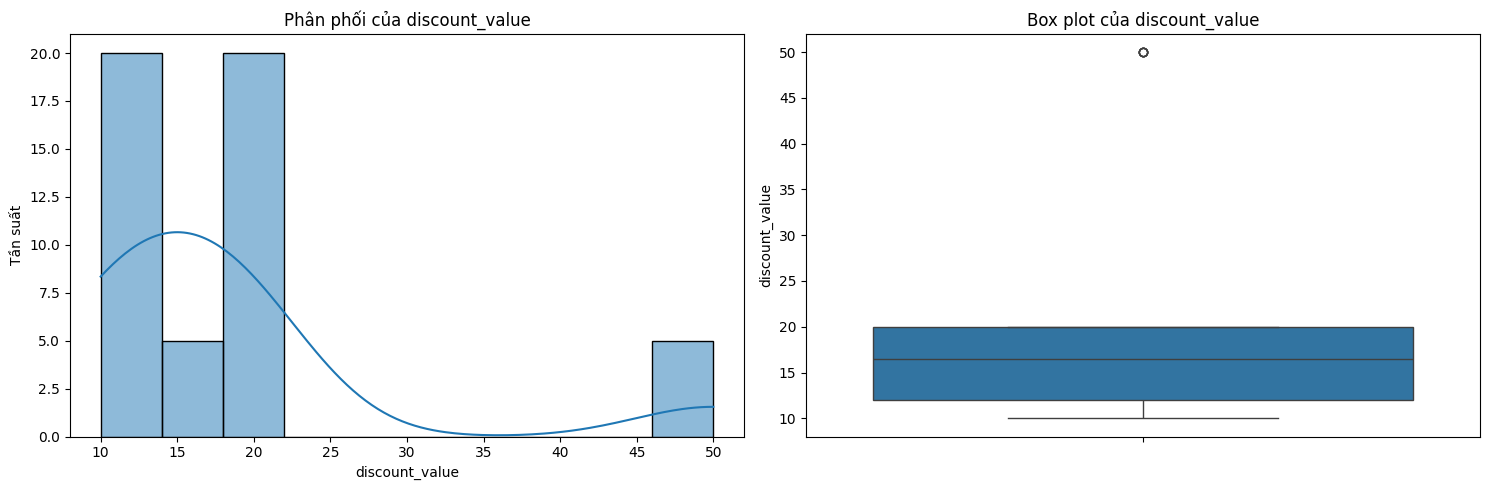

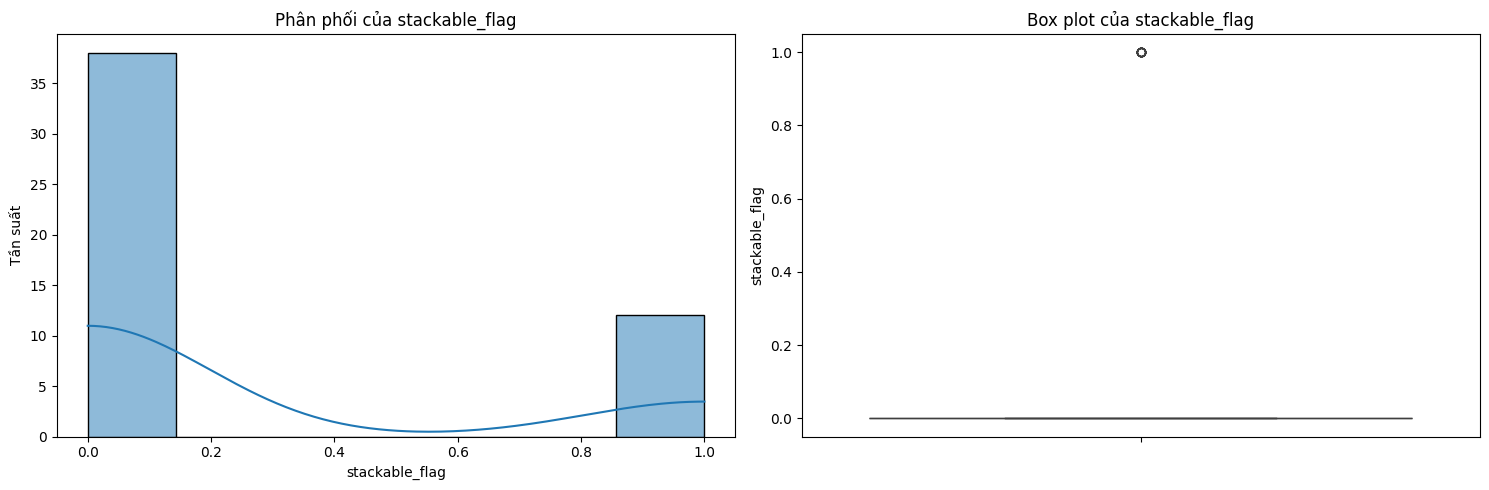

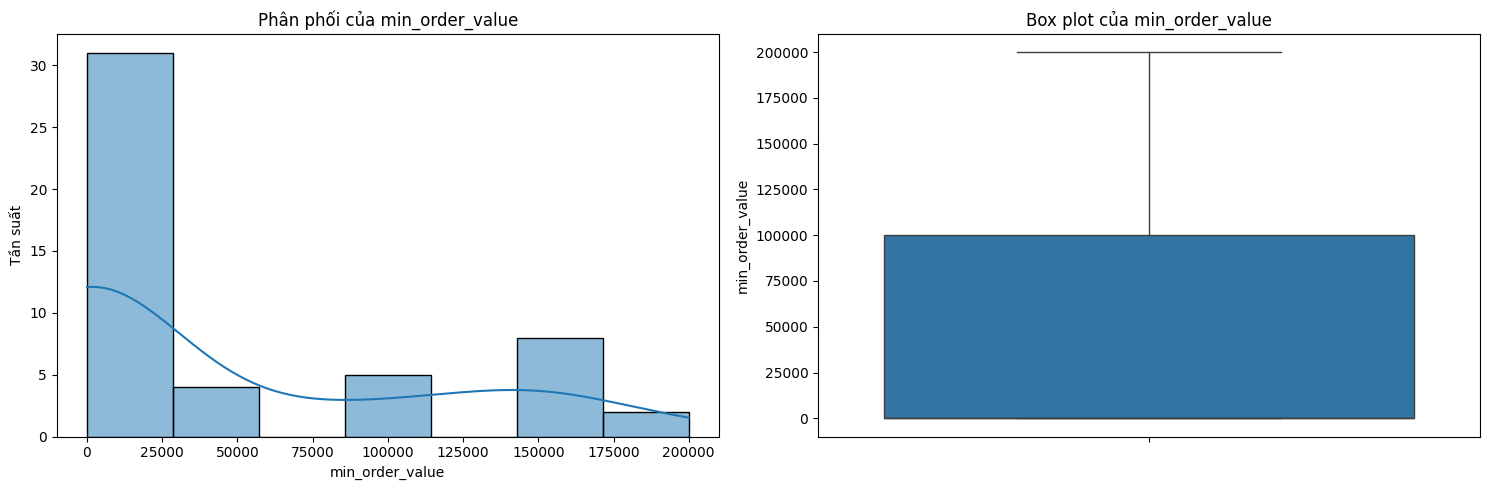

In [37]:
# Lấy danh sách các cột số để phân tích
numerical_cols_promotions = df_promotions.select_dtypes(include=np.number).columns.tolist()

# Đối với promotions, `stackable_flag` là binary, `min_order_value` là số nhưng có thể có nhiều 0, nên vẫn phân tích như số.
# Không có cột ID cần loại bỏ ở đây.

for col in numerical_cols_promotions:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_promotions[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_promotions[col])
    plt.title(f'Box plot của {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Phân tích đơn biến cho các biến định tính

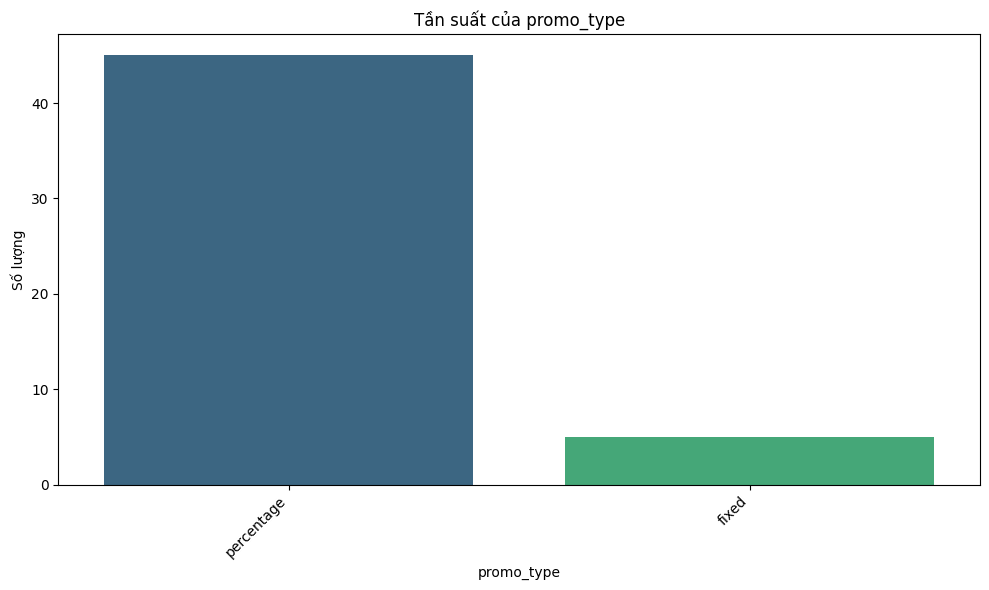

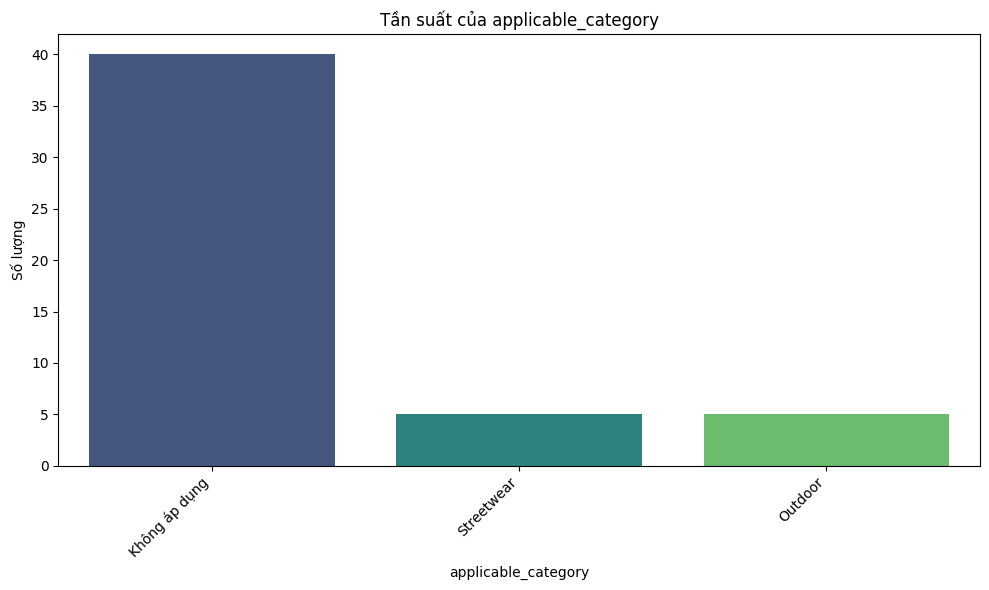

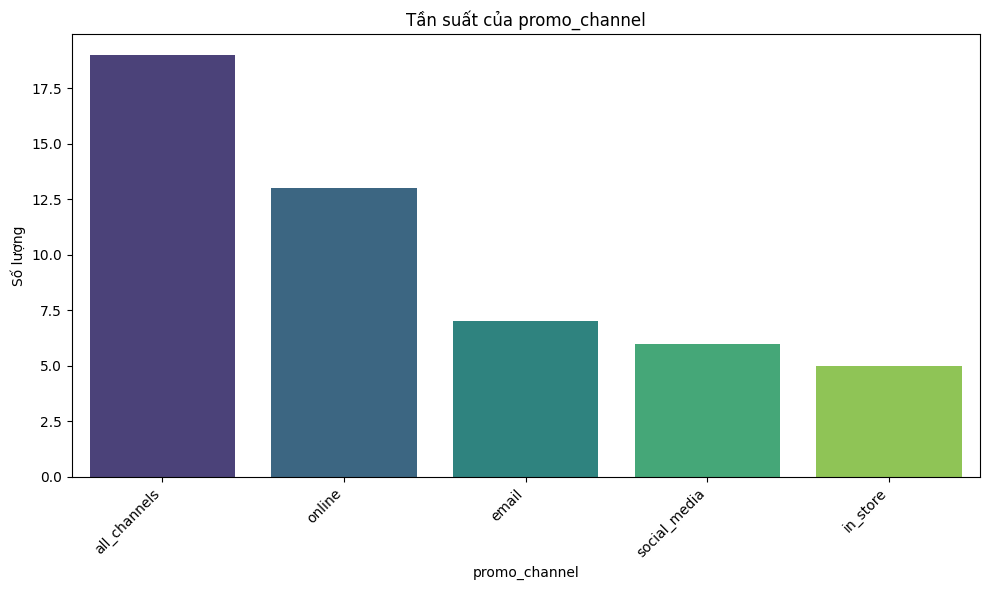

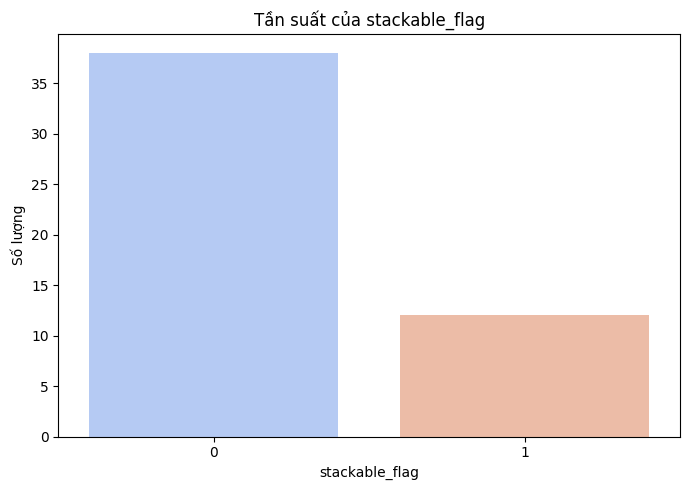

In [38]:
# Lấy danh sách các cột định tính (object)
categorical_cols_promotions = df_promotions.select_dtypes(include='object').columns.tolist()

# Loại bỏ 'promo_id', 'promo_name', 'start_date', 'end_date' để phân tích các biến phân loại thực sự
categorical_cols_promotions = [col for col in categorical_cols_promotions if col not in ['promo_id', 'promo_name', 'start_date', 'end_date']]

for col in categorical_cols_promotions:
    plt.figure(figsize=(10, 6))
    # Sử dụng value_counts() và vẽ bar plot
    # Đối với applicable_category có thể có NaN, nên fillna trước khi đếm hoặc xử lý riêng
    if col == 'applicable_category':
        plot_data = df_promotions[col].fillna('Không áp dụng').value_counts()
    else:
        plot_data = df_promotions[col].value_counts()

    sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')
    plt.title(f'Tần suất của {col}')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Phân tích các cột cờ (binary flags) nếu có (stackable_flag đã nằm trong numerical_cols_promotions, có thể phân tích như định tính nếu muốn)
# Ở đây chúng ta sẽ phân tích lại stackable_flag như một biến định tính để có cái nhìn rõ ràng về tần suất 0 và 1
plt.figure(figsize=(7, 5))
sns.countplot(x=df_promotions['stackable_flag'], palette='coolwarm')
plt.title('Tần suất của stackable_flag')
plt.xlabel('stackable_flag')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

## 6. Phân tích đa biến (Bivariate/Multivariate Analysis):

### Mối quan hệ giữa Discount Value và các biến định tính

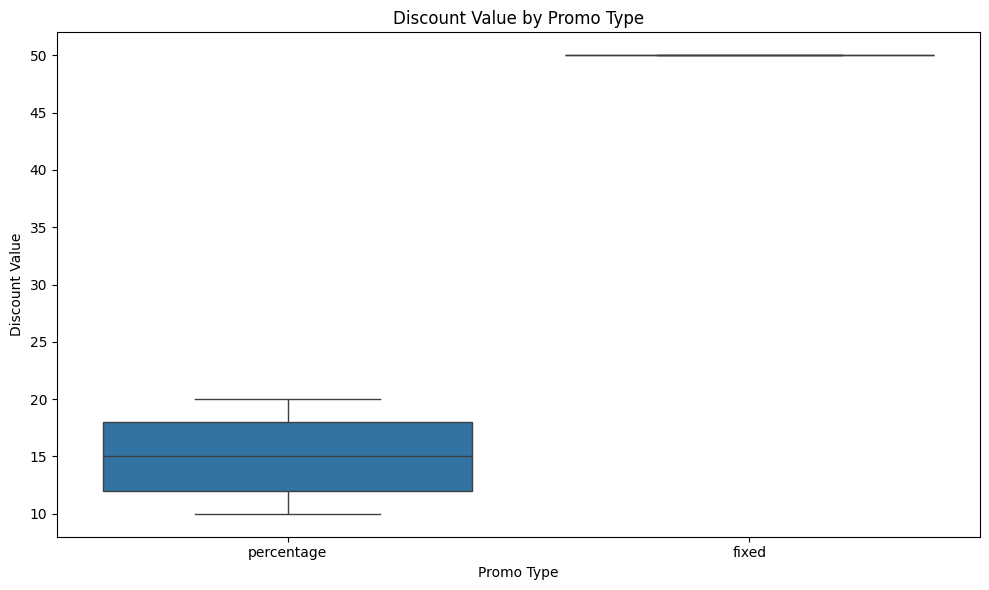

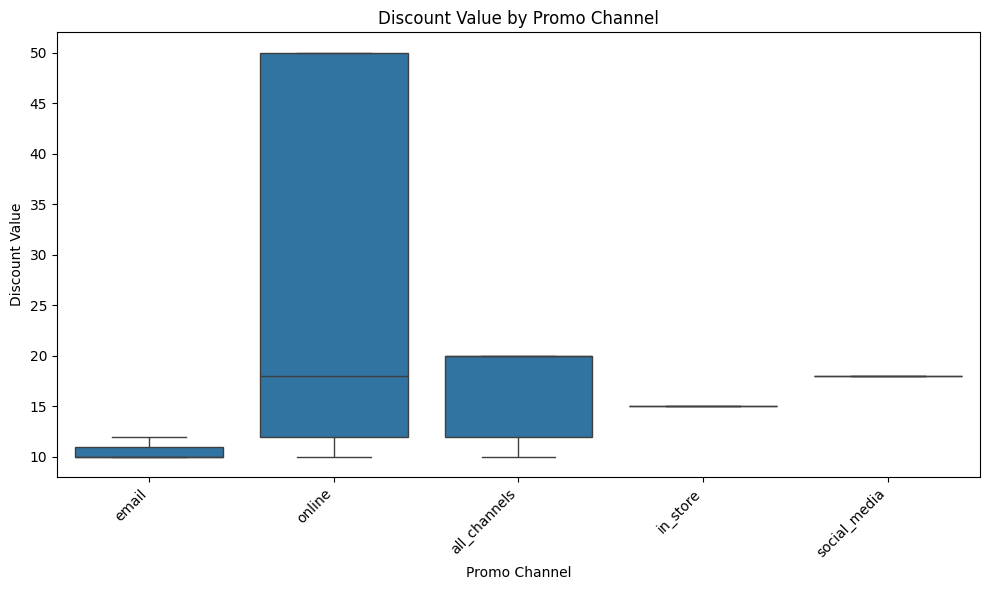

In [39]:
# Box plot của Discount Value theo Promo Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='promo_type', y='discount_value', data=df_promotions)
plt.title('Discount Value by Promo Type')
plt.xlabel('Promo Type')
plt.ylabel('Discount Value')
plt.tight_layout()
plt.show()

# Box plot của Discount Value theo Promo Channel
plt.figure(figsize=(10, 6))
sns.boxplot(x='promo_channel', y='discount_value', data=df_promotions)
plt.title('Discount Value by Promo Channel')
plt.xlabel('Promo Channel')
plt.ylabel('Discount Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Mối quan hệ giữa Stackable Flag và Promo Type/Channel

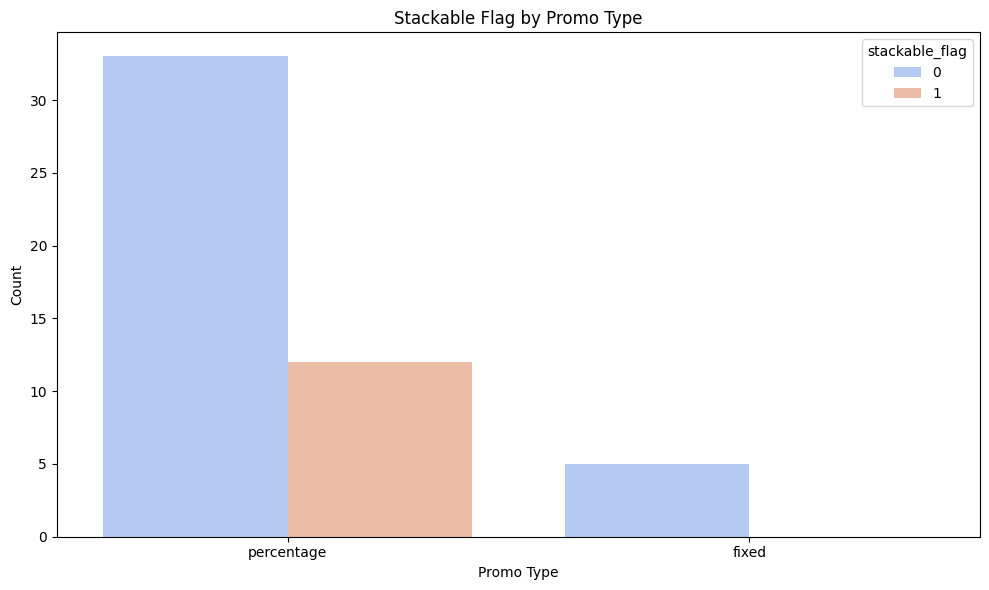

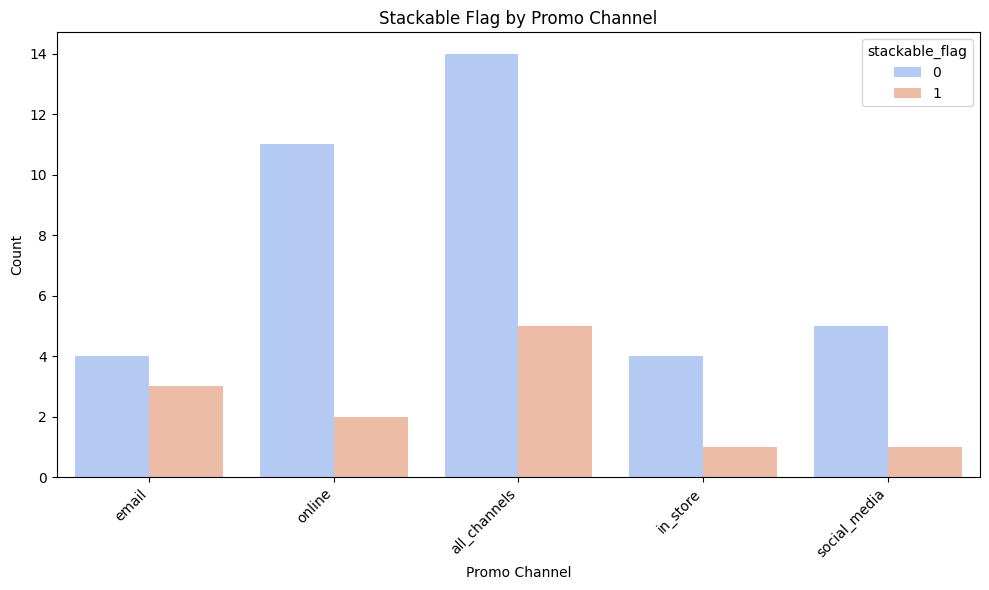

In [40]:
# Count plot của Stackable Flag theo Promo Type
plt.figure(figsize=(10, 6))
sns.countplot(x='promo_type', hue='stackable_flag', data=df_promotions, palette='coolwarm')
plt.title('Stackable Flag by Promo Type')
plt.xlabel('Promo Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Count plot của Stackable Flag theo Promo Channel
plt.figure(figsize=(10, 6))
sns.countplot(x='promo_channel', hue='stackable_flag', data=df_promotions, palette='coolwarm')
plt.title('Stackable Flag by Promo Channel')
plt.xlabel('Promo Channel')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Phát hiện và xử lý ngoại lệ (Outlier Detection):

Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_promotions:

Cột 'discount_value':
  Q1: 12.00, Q3: 20.00, IQR: 8.00
  Ngưỡng dưới (Lower Bound): 0.00
  Ngưỡng trên (Upper Bound): 32.00
  Số lượng ngoại lệ: 5
  Phần trăm ngoại lệ: 10.00%


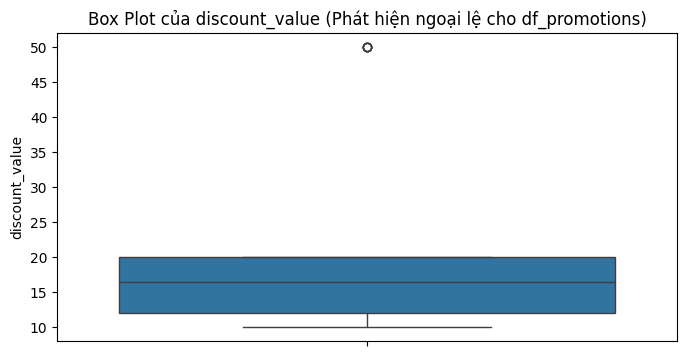


Cột 'min_order_value':
  Q1: 0.00, Q3: 100000.00, IQR: 100000.00
  Ngưỡng dưới (Lower Bound): -150000.00
  Ngưỡng trên (Upper Bound): 250000.00
  Số lượng ngoại lệ: 0


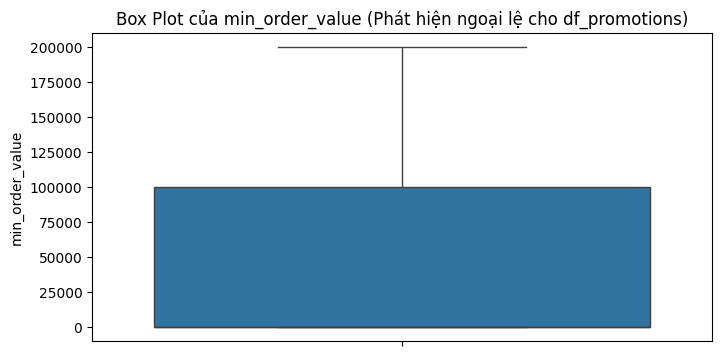

In [41]:
# Lấy danh sách các cột số để phân tích ngoại lệ
numerical_cols_promotions_outliers = [col for col in df_promotions.select_dtypes(include=np.number).columns.tolist() if col not in ['stackable_flag']]

print("Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_promotions:")
for col in numerical_cols_promotions_outliers:
    Q1 = df_promotions[col].quantile(0.25)
    Q3 = df_promotions[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_promotions[(df_promotions[col] < lower_bound) | (df_promotions[col] > upper_bound)]

    print(f"\nCột '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
    print(f"  Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
    print(f"  Số lượng ngoại lệ: {len(outliers)}")
    if not outliers.empty:
        print(f"  Phần trăm ngoại lệ: {len(outliers) / len(df_promotions) * 100:.2f}%")

    # Trực quan hóa ngoại lệ bằng Box Plot
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df_promotions[col])
    plt.title(f'Box Plot của {col} (Phát hiện ngoại lệ cho df_promotions)')
    plt.ylabel(col)
    plt.show()

## 8. Chuyển đổi kiểu dữ liệu (Data Type Conversion):

In [42]:
# Chuyển đổi cột 'start_date' và 'end_date' sang kiểu datetime
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

# Kiểm tra lại thông tin tổng quát để xác nhận kiểu dữ liệu đã thay đổi
print('\nThông tin tổng quát của df_promotions sau khi chuyển đổi kiểu dữ liệu:')
df_promotions.info()


Thông tin tổng quát của df_promotions sau khi chuyển đổi kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     object        
 1   promo_name           50 non-null     object        
 2   promo_type           50 non-null     object        
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[ns]
 5   end_date             50 non-null     datetime64[ns]
 6   applicable_category  10 non-null     object        
 7   promo_channel        50 non-null     object        
 8   stackable_flag       50 non-null     int64         
 9   min_order_value      50 non-null     int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 4.0+ KB


# Returns

| Cột | Kiểu | Mô tả |
| :------------ | :------------ | :------------ |
| `return_id` | `str` | Khoá chính |
| `order_id` | `int` | FK → orders |
| `product_id` | `int` | FK → products |
| `return_date` | `date` | Ngày trả hàng |
| `return_reason` | `str` | Lý do trả hàng |
| `return_quantity` | `int` | Số lượng trả |
| `refund_amount` | `float` | Số tiền hoàn lại |

## 1. Tìm hiểu cấu trúc và tổng quan dữ liệu:

In [43]:
print('5 dòng đầu của df_returns:')
display(df_returns.head())

5 dòng đầu của df_returns:


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


In [44]:
print('Thông tin tổng quát của df_returns:')
df_returns.info()

Thông tin tổng quát của df_returns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   return_id        39939 non-null  object 
 1   order_id         39939 non-null  int64  
 2   product_id       39939 non-null  int64  
 3   return_date      39939 non-null  object 
 4   return_reason    39939 non-null  object 
 5   return_quantity  39939 non-null  int64  
 6   refund_amount    39939 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 2.1+ MB


In [45]:
print('Kích thước của df_returns:')
df_returns.shape

Kích thước của df_returns:


(39939, 7)

## 2. Thống kê mô tả:

In [46]:
# Thống kê mô tả cho df_returns
df_returns.describe()

,order_id,product_id,return_quantity,refund_amount
count,39939.000000,39939.000000,39939.000000,39939.000000
mean,409061.984176,1244.232730,2.743834,12784.458964
std,240063.904576,691.747822,1.828260,14092.150154
min,2.000000,3.000000,1.000000,458.810000
25%,202651.000000,702.000000,1.000000,3573.395000
50%,404254.000000,992.000000,2.000000,7888.880000
75%,615620.000000,2048.000000,4.000000,16881.990000
max,833351.000000,2412.000000,8.000000,160937.940000


## 3. Kiểm tra và xử lý dữ liệu thiếu (Missing Values):

In [47]:
# Kiểm tra dữ liệu thiếu
print(df_returns.isnull().sum())

return_id          0
order_id           0
product_id         0
return_date        0
return_reason      0
return_quantity    0
refund_amount      0
dtype: int64


## 4. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicate Values):

In [48]:
# Kiểm tra dữ liệu trùng lặp
print(df_returns.duplicated().sum())

0


## 5. Phân tích đơn biến (Univariate Analysis):

### Phân tích đơn biến cho các biến định lượng

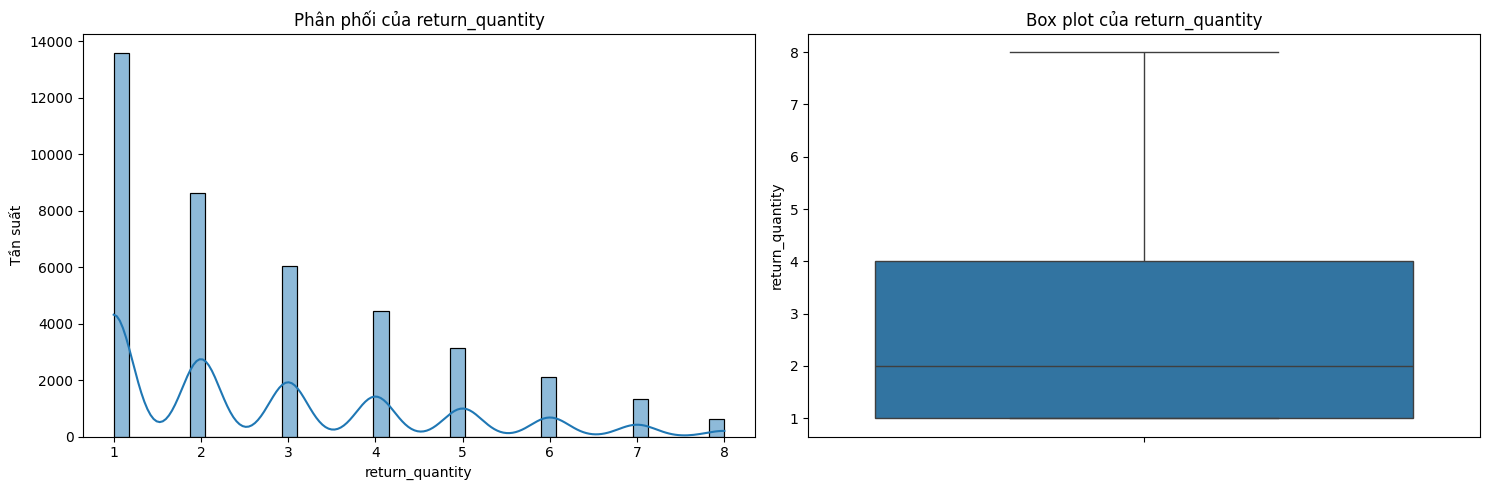

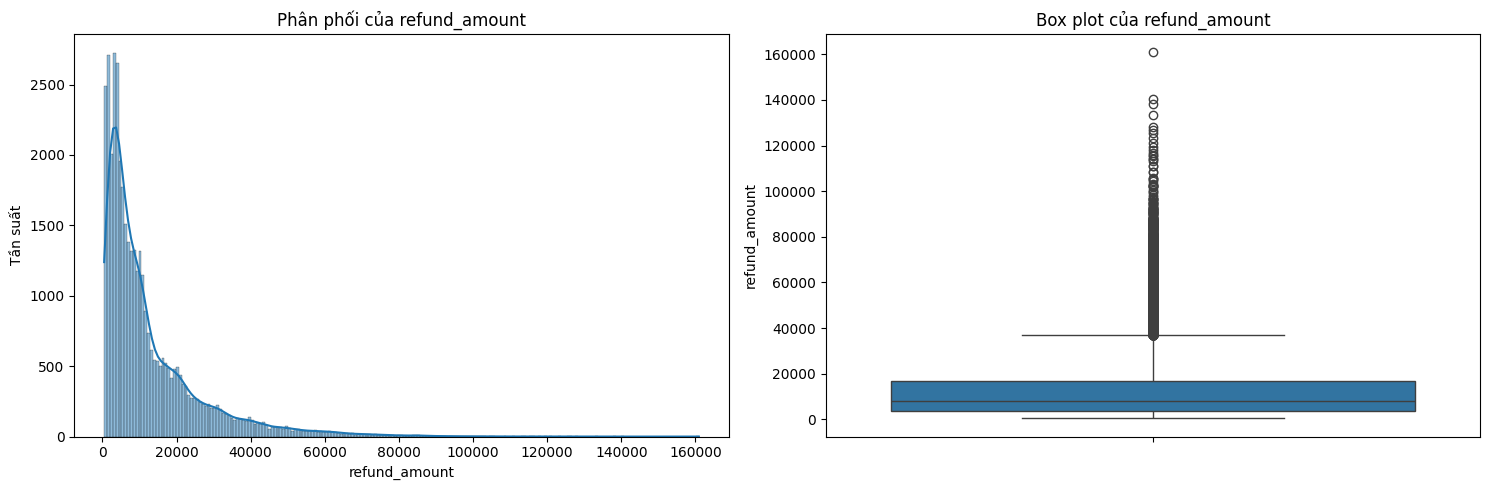

In [49]:
# Lấy danh sách các cột số để phân tích
numerical_cols_returns = df_returns.select_dtypes(include=np.number).columns.tolist()

# Loại bỏ các cột ID
numerical_cols_returns = [col for col in numerical_cols_returns if col not in ['return_id', 'order_id', 'product_id']]

for col in numerical_cols_returns:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_returns[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_returns[col])
    plt.title(f'Box plot của {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Phân tích đơn biến cho các biến định tính

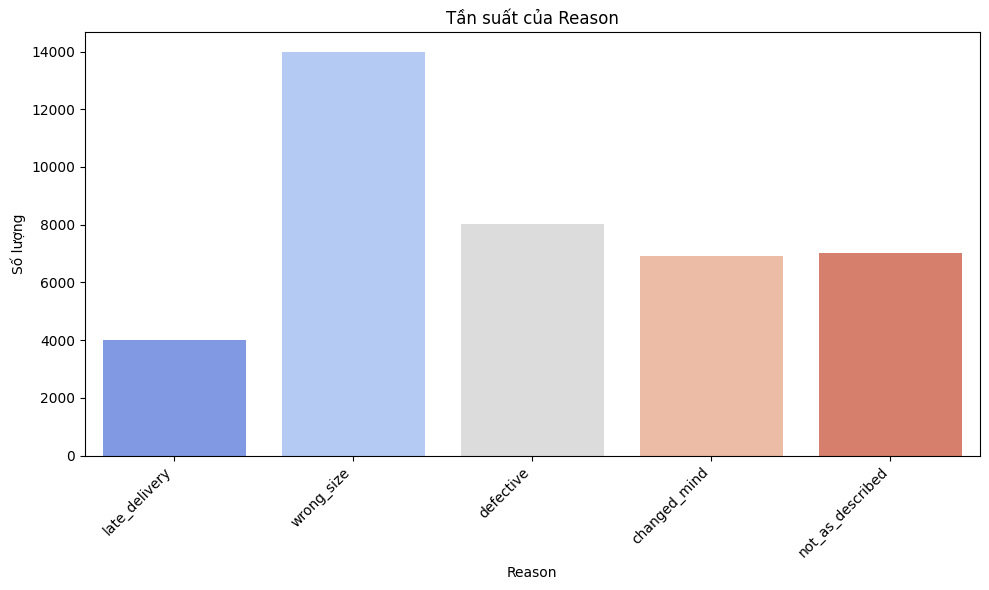

In [50]:
# Phân tích cột 'return_reason'
plt.figure(figsize=(10, 6))
sns.countplot(x='return_reason', data=df_returns, palette='coolwarm')
plt.title('Tần suất của Reason')
plt.xlabel('Reason')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Phân tích đa biến (Bivariate/Multivariate Analysis):

### Mối quan hệ giữa Returned Quantity và các biến định tính

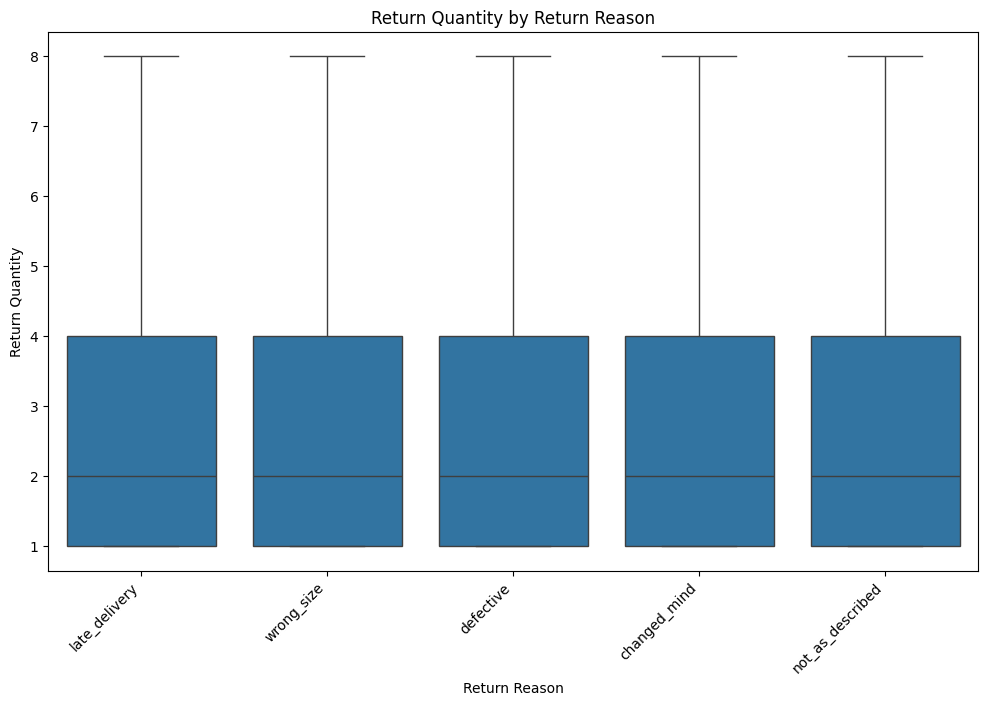

In [51]:
# Box plot của Return Quantity theo Return Reason
plt.figure(figsize=(12, 7))
sns.boxplot(x='return_reason', y='return_quantity', data=df_returns)
plt.title('Return Quantity by Return Reason')
plt.xlabel('Return Reason')
plt.ylabel('Return Quantity')
plt.xticks(rotation=45, ha='right')
plt.show()

## 7. Phát hiện và xử lý ngoại lệ (Outlier Detection):

Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_returns:

Cột 'return_quantity':
  Q1: 1.00, Q3: 4.00, IQR: 3.00
  Ngưỡng dưới (Lower Bound): -3.50
  Ngưỡng trên (Upper Bound): 8.50
  Số lượng ngoại lệ: 0


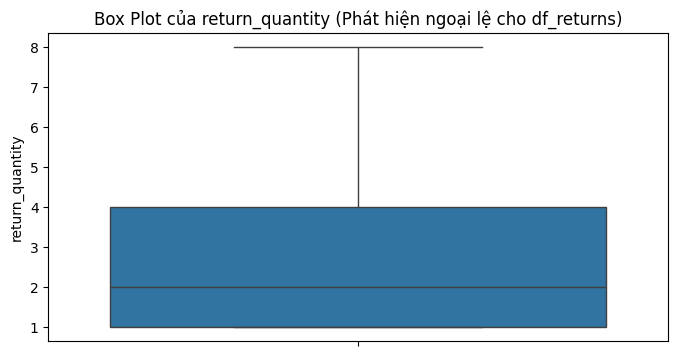


Cột 'refund_amount':
  Q1: 3573.39, Q3: 16881.99, IQR: 13308.59
  Ngưỡng dưới (Lower Bound): -16389.50
  Ngưỡng trên (Upper Bound): 36844.88
  Số lượng ngoại lệ: 2778
  Phần trăm ngoại lệ: 6.96%


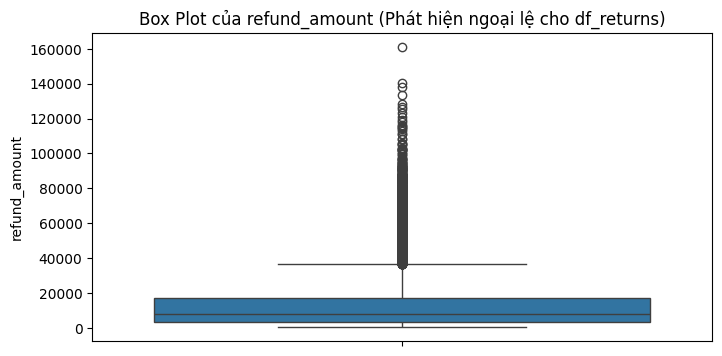

In [52]:
# Lấy danh sách các cột số để phân tích ngoại lệ
numerical_cols_returns_outliers = [col for col in df_returns.select_dtypes(include=np.number).columns.tolist() if col not in ['return_id', 'order_id', 'product_id']]

print("Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_returns:")
for col in numerical_cols_returns_outliers:
    Q1 = df_returns[col].quantile(0.25)
    Q3 = df_returns[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_returns[(df_returns[col] < lower_bound) | (df_returns[col] > upper_bound)]

    print(f"\nCột '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
    print(f"  Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
    print(f"  Số lượng ngoại lệ: {len(outliers)}")
    if not outliers.empty:
        print(f"  Phần trăm ngoại lệ: {len(outliers) / len(df_returns) * 100:.2f}%")

    # Trực quan hóa ngoại lệ bằng Box Plot
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df_returns[col])
    plt.title(f'Box Plot của {col} (Phát hiện ngoại lệ cho df_returns)')
    plt.ylabel(col)
    plt.show()

## 8. Chuyển đổi kiểu dữ liệu (Data Type Conversion):

In [53]:
# Chuyển đổi cột 'return_date' sang kiểu datetime
df_returns['return_date'] = pd.to_datetime(df_returns['return_date'])

# Kiểm tra lại thông tin tổng quát để xác nhận kiểu dữ liệu đã thay đổi
print('\nThông tin tổng quát của df_returns sau khi chuyển đổi kiểu dữ liệu:')
df_returns.info()


Thông tin tổng quát của df_returns sau khi chuyển đổi kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   return_id        39939 non-null  object        
 1   order_id         39939 non-null  int64         
 2   product_id       39939 non-null  int64         
 3   return_date      39939 non-null  datetime64[ns]
 4   return_reason    39939 non-null  object        
 5   return_quantity  39939 non-null  int64         
 6   refund_amount    39939 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 2.1+ MB


# Sales

| Cột | Kiểu | Mô tả |
| :------------ | :------------ | :------------ |
| `Date` | `date` | Ngày đặt hàng |
| `Revenue` | `float` | Tổng doanh thu thuần |
| `COGS` | `float` | Tổng giá vốn hàng bán |

## 1. Tìm hiểu cấu trúc và tổng quan dữ liệu:

In [54]:
print('5 dòng đầu của df_sales:')
display(df_sales.head())

5 dòng đầu của df_sales:


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [55]:
print('Thông tin tổng quát của df_sales:')
df_sales.info()

Thông tin tổng quát của df_sales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   object 
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), object(1)
memory usage: 90.0+ KB


In [56]:
print('Kích thước của df_sales:')
df_sales.shape

Kích thước của df_sales:


(3833, 3)

## 2. Thống kê mô tả:

In [57]:
# Thống kê mô tả cho df_sales
display(df_sales.describe())

,Revenue,COGS
count,3.833000e+03,3.833000e+03
mean,4.286584e+06,3.695134e+06
std,2.624840e+06,2.219789e+06
min,2.798139e+05,2.365763e+05
25%,2.471089e+06,2.150580e+06
50%,3.647304e+06,3.161113e+06
75%,5.350877e+06,4.637294e+06
max,2.090527e+07,1.653586e+07


## 3. Kiểm tra và xử lý dữ liệu thiếu (Missing Values):

In [58]:
# Kiểm tra dữ liệu thiếu
print(df_sales.isnull().sum())

Date       0
Revenue    0
COGS       0
dtype: int64


## 4. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicate Values):

In [59]:
# Kiểm tra dữ liệu trùng lặp
print(df_sales.duplicated().sum())

0


## 5. Phân tích đơn biến (Univariate Analysis):

### Phân tích đơn biến cho các biến định lượng

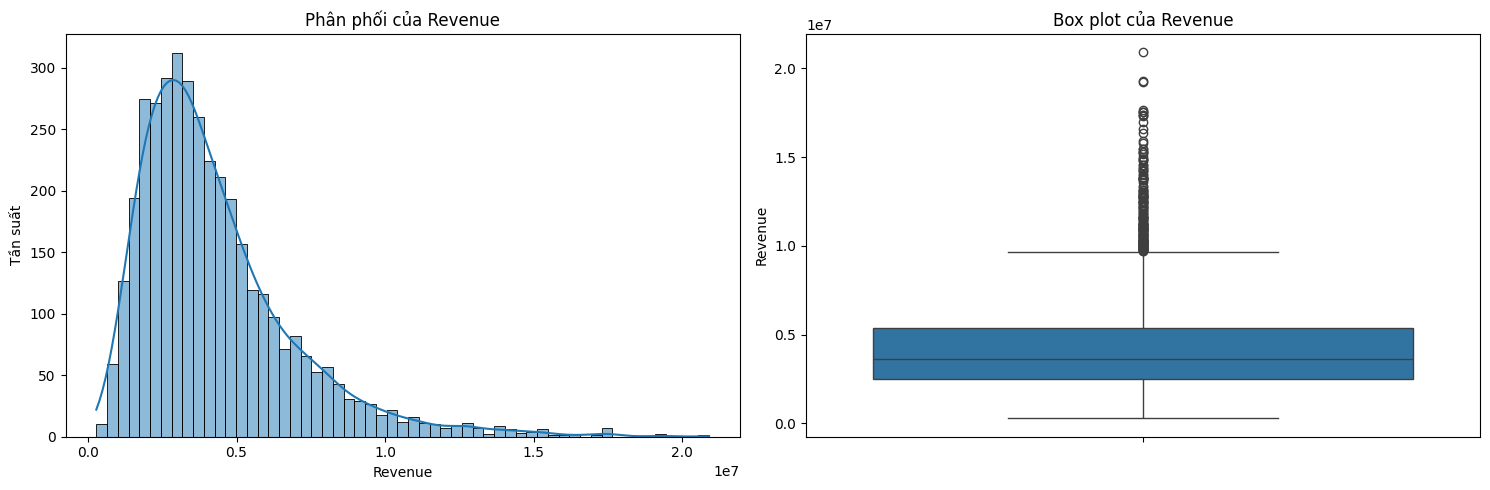

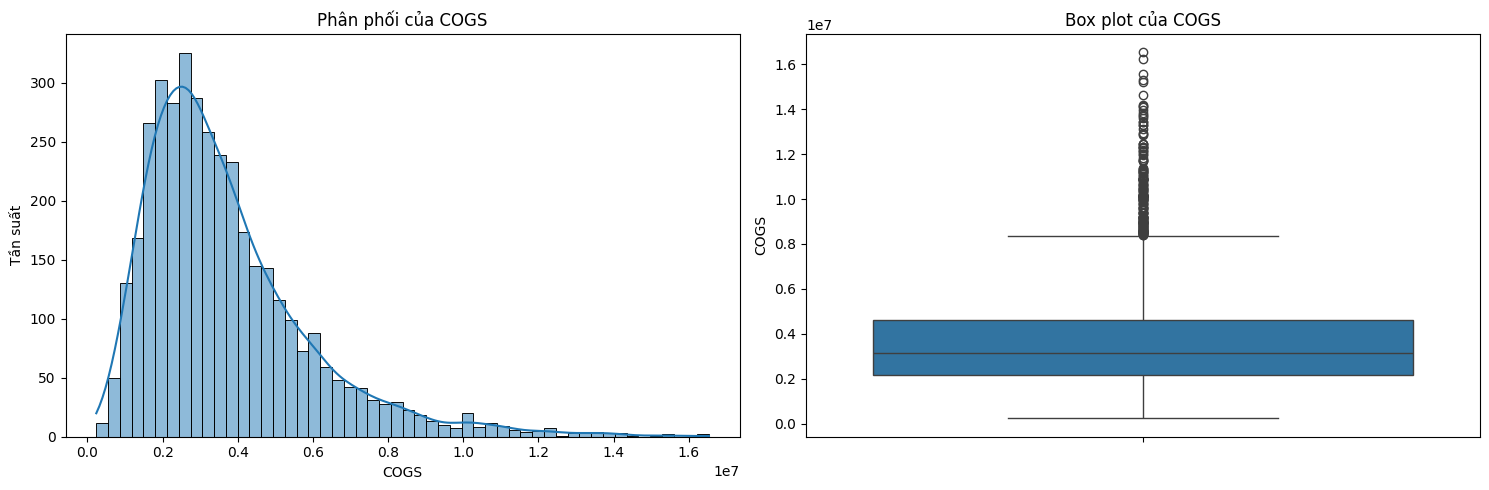

In [60]:
# Lấy danh sách các cột số để phân tích
numerical_cols_sales = df_sales.select_dtypes(include=np.number).columns.tolist()

# Loại bỏ các cột ID
numerical_cols_sales = [col for col in numerical_cols_sales if col not in ['order_id', 'product_id', 'customer_id']]

for col in numerical_cols_sales:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_sales[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_sales[col])
    plt.title(f'Box plot của {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 6. Phân tích đa biến (Bivariate/Multivariate Analysis):

### Ma trận tương quan giữa các biến số

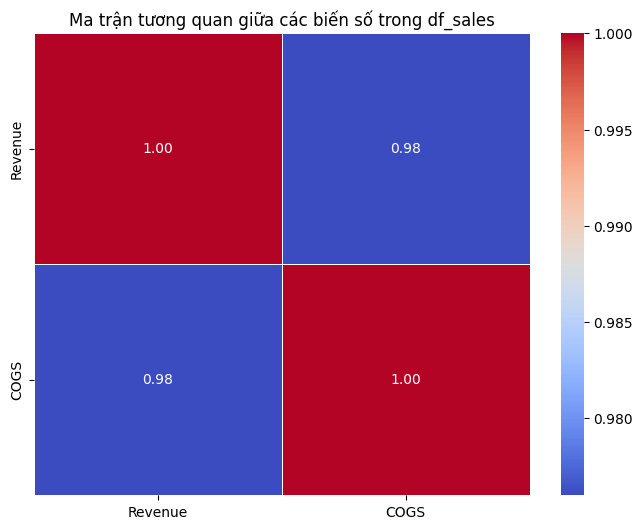

In [61]:
# Chọn các cột số liên quan để tính ma trận tương quan
correlation_cols_sales = ['Revenue', 'COGS']

# Tính ma trận tương quan
corr_matrix_sales = df_sales[correlation_cols_sales].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_sales, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Ma trận tương quan giữa các biến số trong df_sales')
plt.show()

## 7. Phát hiện và xử lý ngoại lệ (Outlier Detection):

Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_sales:

Cột 'Revenue':
  Q1: 2471088.82, Q3: 5350877.20, IQR: 2879788.38
  Ngưỡng dưới (Lower Bound): -1848593.75
  Ngưỡng trên (Upper Bound): 9670559.77
  Số lượng ngoại lệ: 169
  Phần trăm ngoại lệ: 4.41%


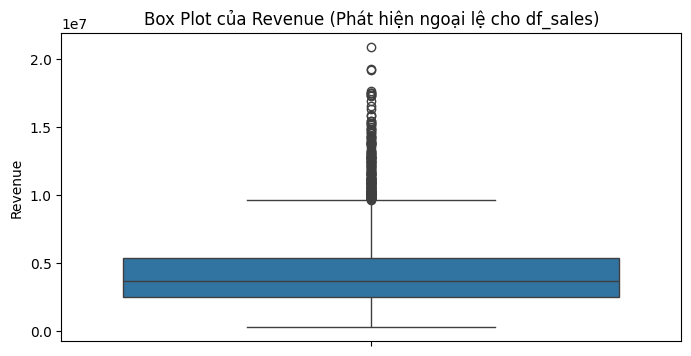


Cột 'COGS':
  Q1: 2150580.23, Q3: 4637293.92, IQR: 2486713.69
  Ngưỡng dưới (Lower Bound): -1579490.31
  Ngưỡng trên (Upper Bound): 8367364.46
  Số lượng ngoại lệ: 165
  Phần trăm ngoại lệ: 4.30%


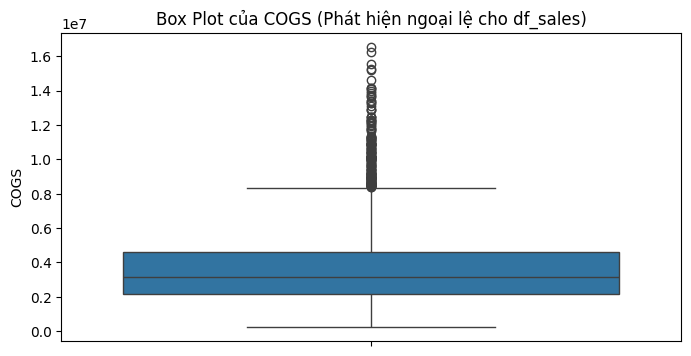

In [62]:
# Lấy danh sách các cột số để phân tích ngoại lệ
# Loại bỏ các cột ID
numerical_cols_sales_outliers = [col for col in df_sales.select_dtypes(include=np.number).columns.tolist()]

print("Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_sales:")
for col in numerical_cols_sales_outliers:
    Q1 = df_sales[col].quantile(0.25)
    Q3 = df_sales[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_sales[(df_sales[col] < lower_bound) | (df_sales[col] > upper_bound)]

    print(f"\nCột '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
    print(f"  Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
    print(f"  Số lượng ngoại lệ: {len(outliers)}")
    if not outliers.empty:
        print(f"  Phần trăm ngoại lệ: {len(outliers) / len(df_sales) * 100:.2f}%")

    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df_sales[col])
    plt.title(f'Box Plot của {col} (Phát hiện ngoại lệ cho df_sales)')
    plt.ylabel(col)
    plt.show()

## 8. Chuyển đổi kiểu dữ liệu (Data Type Conversion):

In [63]:
# Chuyển đổi cột 'Date' sang kiểu datetime
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Kiểm tra lại thông tin tổng quát để xác nhận kiểu dữ liệu đã thay đổi
print('\nThông tin tổng quát của df_sales sau khi chuyển đổi kiểu dữ liệu:')
df_sales.info()


Thông tin tổng quát của df_sales sau khi chuyển đổi kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[ns]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 90.0 KB


# Sample Submission

| Cột | Kiểu | Mô tả |
| :------------ | :------------ | :------------ |
| `Date` | `date` | Ngày đặt hàng |
| `Revenue` | `float` | Tổng doanh thu thuần |
| `COGS` | `float` | Tổng giá vốn hàng bán |

## 1. Tìm hiểu cấu trúc và tổng quan dữ liệu:

In [64]:
print('5 dòng đầu của df_submission:')
display(df_submission.head())

5 dòng đầu của df_submission:


,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24


In [65]:
print('Thông tin tổng quát của df_submission:')
df_submission.info()

Thông tin tổng quát của df_submission:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     548 non-null    object 
 1   Revenue  548 non-null    float64
 2   COGS     548 non-null    float64
dtypes: float64(2), object(1)
memory usage: 13.0+ KB


In [66]:
print('Kích thước của df_submission:')
df_submission.shape

Kích thước của df_submission:


(548, 3)

## 2. Thống kê mô tả:

In [67]:
# Thống kê mô tả cho df_submission
display(df_submission.describe())

,Revenue,COGS
count,5.480000e+02,5.480000e+02
mean,3.249795e+06,2.783810e+06
std,1.581698e+06,1.360346e+06
min,9.773328e+05,7.902589e+05
25%,2.032802e+06,1.706747e+06
50%,2.968953e+06,2.575698e+06
75%,4.182023e+06,3.515931e+06
max,9.283417e+06,8.341542e+06


## 3. Kiểm tra và xử lý dữ liệu thiếu (Missing Values):

In [68]:
# Kiểm tra dữ liệu thiếu
print(df_submission.isnull().sum())

Date       0
Revenue    0
COGS       0
dtype: int64


## 4. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicate Values):

In [69]:
# Kiểm tra dữ liệu trùng lặp
print(df_submission.duplicated().sum())

0


## 5. Phân tích đơn biến (Univariate Analysis):

### Phân tích đơn biến cho các biến định lượng

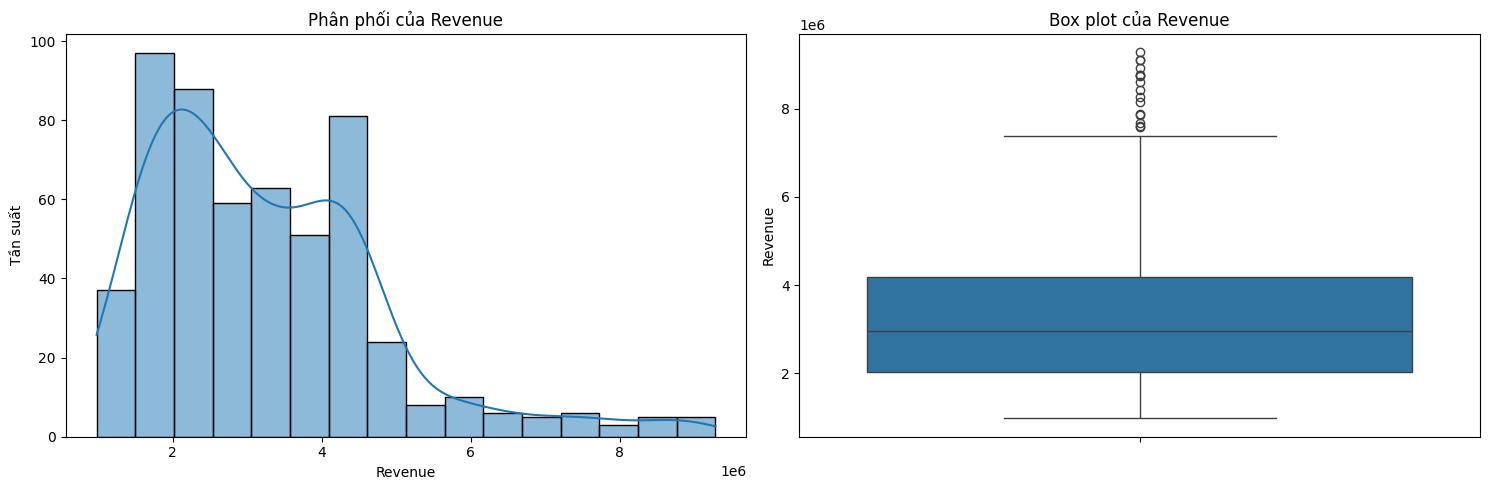

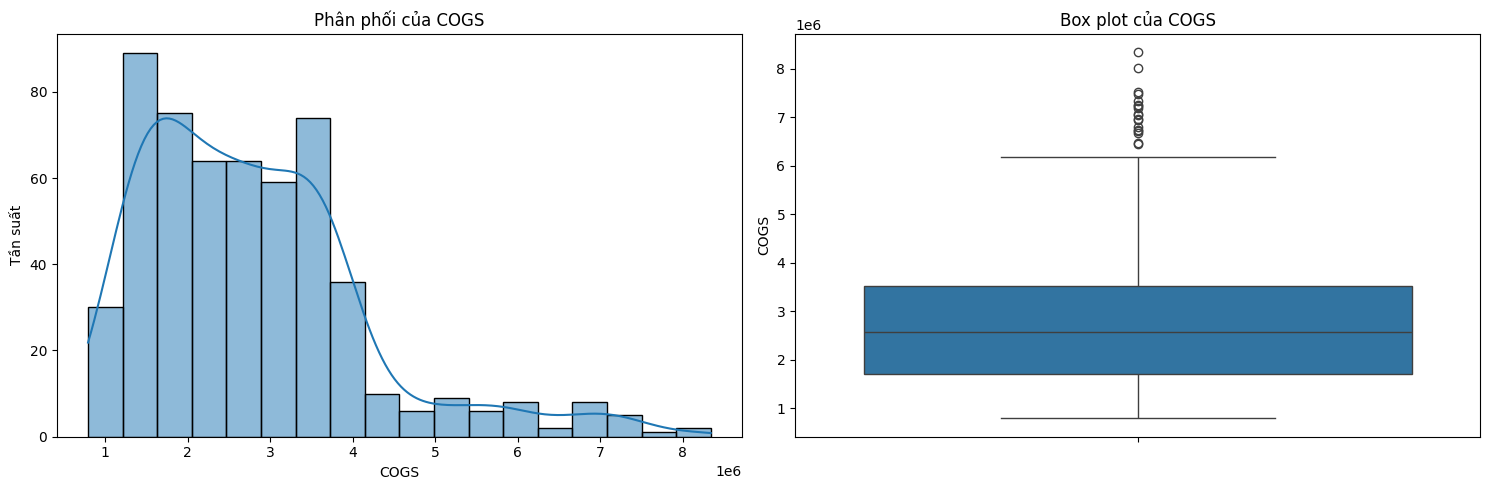

In [70]:
# Lấy danh sách các cột số để phân tích
numerical_cols_submission = df_submission.select_dtypes(include=np.number).columns.tolist()

# 'id' thường là cột định danh, nên loại bỏ nếu muốn phân tích phân phối giá trị.
numerical_cols_submission = [col for col in numerical_cols_submission if col not in ['id']]

for col in numerical_cols_submission:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_submission[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_submission[col])
    plt.title(f'Box plot của {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 6. Phân tích đa biến (Bivariate/Multivariate Analysis):

### Ma trận tương quan giữa các biến số

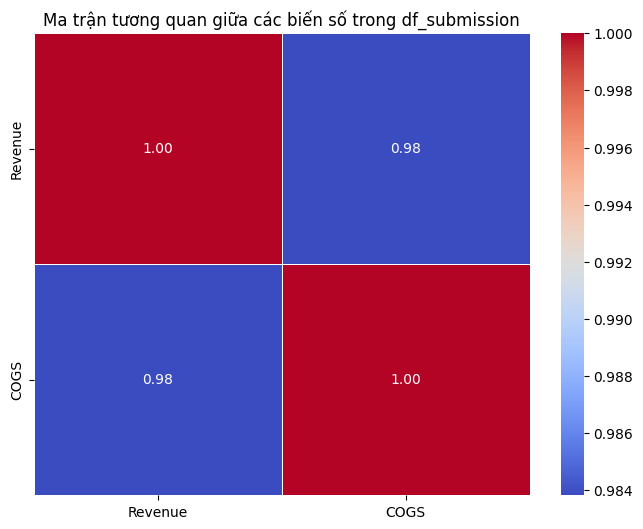

In [71]:
# Chọn các cột số liên quan để tính ma trận tương quan
# Trong file submission, thường chỉ có 1 cột 'prediction' hoặc 'target' cần phân tích, ngoài cột 'id'.
# Nếu có nhiều cột số khác, có thể thêm vào đây.
correlation_cols_submission = df_submission.select_dtypes(include=np.number).columns.tolist()
correlation_cols_submission = [col for col in correlation_cols_submission if col not in ['id']]

if len(correlation_cols_submission) > 1:
    corr_matrix_submission = df_submission[correlation_cols_submission].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix_submission, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Ma trận tương quan giữa các biến số trong df_submission')
    plt.show()
else:
    print(f"Chỉ có {len(correlation_cols_submission)} cột số không phải 'id' trong df_submission. Không thể tạo ma trận tương quan.")

## 7. Phát hiện và xử lý ngoại lệ (Outlier Detection):

Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_submission:

Cột 'Revenue':
  Q1: 2032802.20, Q3: 4182023.09, IQR: 2149220.89
  Ngưỡng dưới (Lower Bound): -1191029.14
  Ngưỡng trên (Upper Bound): 7405854.44
  Số lượng ngoại lệ: 16
  Phần trăm ngoại lệ: 2.92%


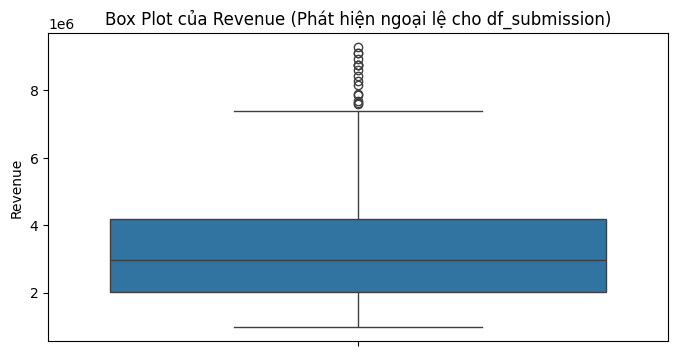


Cột 'COGS':
  Q1: 1706746.74, Q3: 3515931.00, IQR: 1809184.26
  Ngưỡng dưới (Lower Bound): -1007029.66
  Ngưỡng trên (Upper Bound): 6229707.40
  Số lượng ngoại lệ: 18
  Phần trăm ngoại lệ: 3.28%


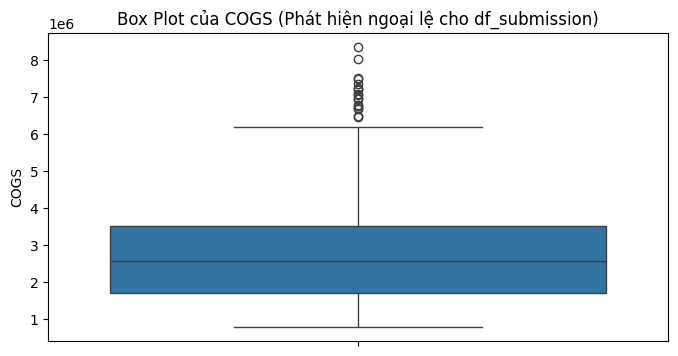

In [72]:
# Lấy danh sách các cột số để phân tích ngoại lệ
numerical_cols_submission_outliers = df_submission.select_dtypes(include=np.number).columns.tolist()

# Loại bỏ 'id' vì đây là định danh
numerical_cols_submission_outliers = [col for col in numerical_cols_submission_outliers if col not in ['id']]

print("Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_submission:")
for col in numerical_cols_submission_outliers:
    Q1 = df_submission[col].quantile(0.25)
    Q3 = df_submission[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_submission[(df_submission[col] < lower_bound) | (df_submission[col] > upper_bound)]

    print(f"\nCột '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
    print(f"  Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
    print(f"  Số lượng ngoại lệ: {len(outliers)}")
    if not outliers.empty:
        print(f"  Phần trăm ngoại lệ: {len(outliers) / len(df_submission) * 100:.2f}%")

    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df_submission[col])
    plt.title(f'Box Plot của {col} (Phát hiện ngoại lệ cho df_submission)')
    plt.ylabel(col)
    plt.show()

## 8. Chuyển đổi kiểu dữ liệu (Data Type Conversion):

In [73]:
# Chuyển đổi cột 'Date' sang kiểu datetime
df_submission['Date'] = pd.to_datetime(df_submission['Date'])

# Kiểm tra lại thông tin tổng quát để xác nhận kiểu dữ liệu đã thay đổi
print('\nThông tin tổng quát của df_submission sau khi chuyển đổi kiểu dữ liệu:')
df_submission.info()


Thông tin tổng quát của df_submission sau khi chuyển đổi kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     548 non-null    datetime64[ns]
 1   Revenue  548 non-null    float64       
 2   COGS     548 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 13.0 KB


# Web Traffic

| Cột | Kiểu | Mô tả |
| :------------ | :------------ | :------------ |
| `date` | `date` | Ngày ghi nhận |
| `sessions` | `int` | Tổng số phiên truy cập |
| `unique_visitors` | `int` | Khách truy cập duy nhất |
| `page_views` | `int` | Tổng lượt xem trang |
| `bounce_rate` | `float` | Tỷ lệ thoát |
| `avg_session_duration_sec` | `float` | Thời gian trung bình / phiên (giây) |
| `conversion_rate` | `float` | Tỷ lệ phiên dẫn đến đặt hàng |
| `traffic_source` | `str` | Kênh nguồn traffic |

## 1. Tìm hiểu cấu trúc và tổng quan dữ liệu:

In [74]:
print('5 dòng đầu của df_web_traffic:')
display(df_web_traffic.head())

5 dòng đầu của df_web_traffic:


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


In [75]:
print('Thông tin tổng quát của df_web_traffic:')
df_web_traffic.info()

Thông tin tổng quát của df_web_traffic:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      3652 non-null   object 
 1   sessions                  3652 non-null   int64  
 2   unique_visitors           3652 non-null   int64  
 3   page_views                3652 non-null   int64  
 4   bounce_rate               3652 non-null   float64
 5   avg_session_duration_sec  3652 non-null   float64
 6   traffic_source            3652 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 199.8+ KB


In [76]:
print('Kích thước của df_web_traffic:')
df_web_traffic.shape

Kích thước của df_web_traffic:


(3652, 7)

## 2. Thống kê mô tả:

In [77]:
# Thống kê mô tả cho df_web_traffic
display(df_web_traffic.describe())

,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
count,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,25041.768072,19031.404436,108615.224535,0.004487,210.283242
std,9422.609335,7237.953062,44472.055524,0.000753,63.771711
min,7973.000000,6136.000000,30451.000000,0.003200,100.100000
25%,17099.250000,12915.000000,72982.000000,0.003848,156.700000
50%,23633.500000,17924.000000,101010.500000,0.004450,209.200000
75%,31782.750000,24191.750000,138086.000000,0.005160,266.200000
max,50947.000000,40430.000000,275560.000000,0.005800,319.900000


## 3. Kiểm tra và xử lý dữ liệu thiếu (Missing Values):

In [78]:
# Kiểm tra dữ liệu thiếu
print(df_web_traffic.isnull().sum())

date                        0
sessions                    0
unique_visitors             0
page_views                  0
bounce_rate                 0
avg_session_duration_sec    0
traffic_source              0
dtype: int64


## 4. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicate Values):

In [79]:
# Kiểm tra dữ liệu trùng lặp
print(df_web_traffic.duplicated().sum())

0


## 5. Phân tích đơn biến (Univariate Analysis):

### Phân tích đơn biến cho các biến định lượng

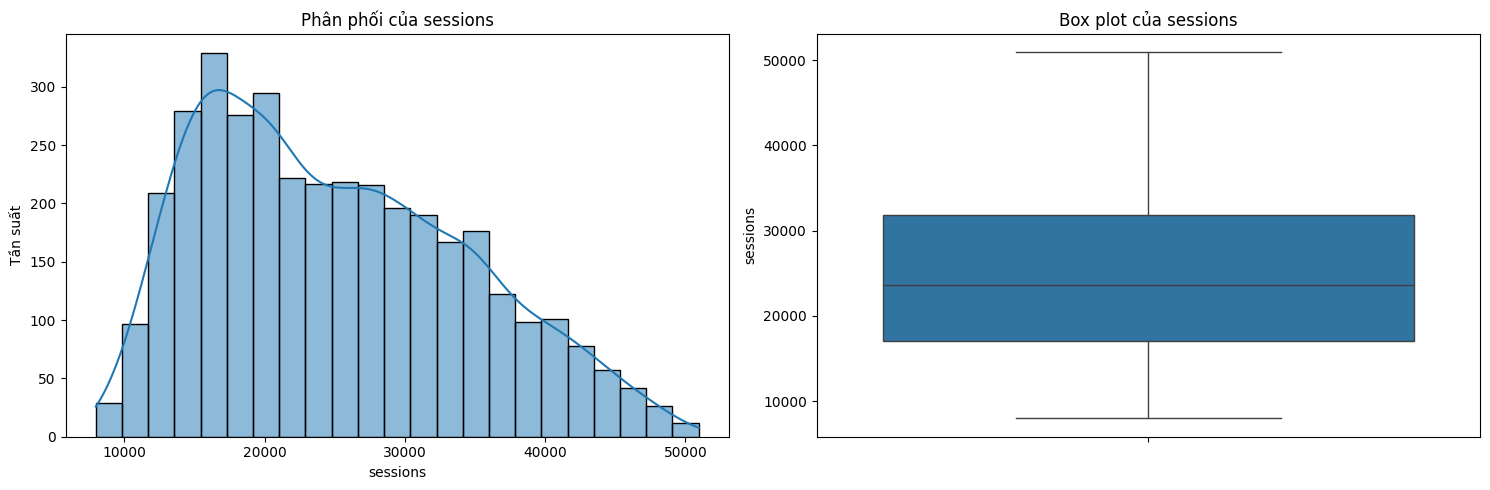

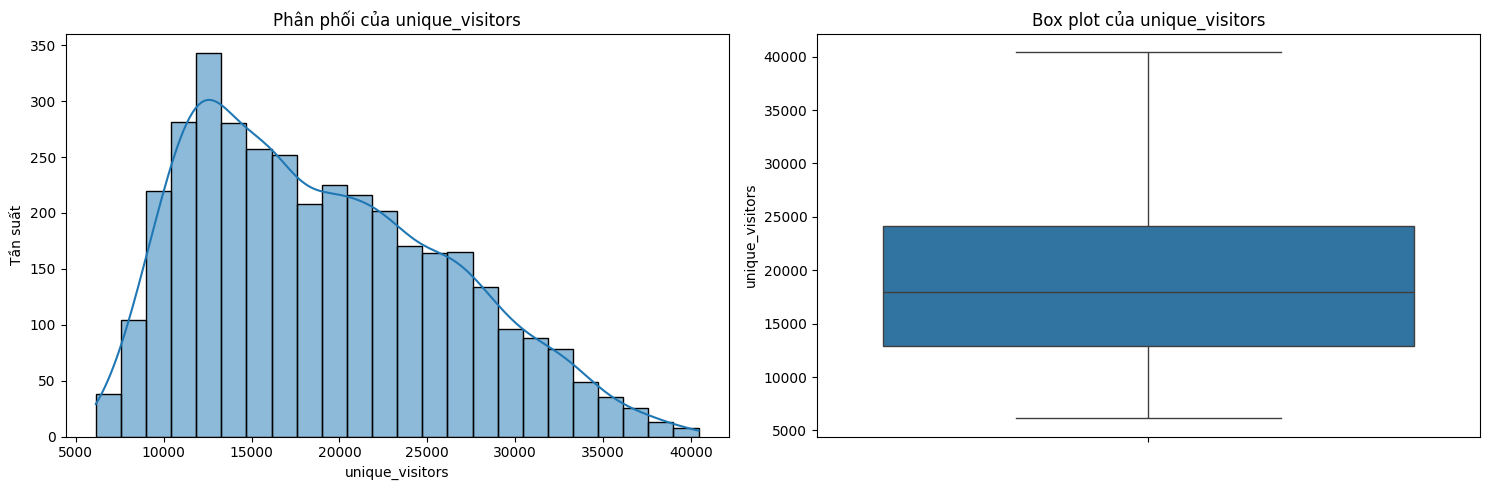

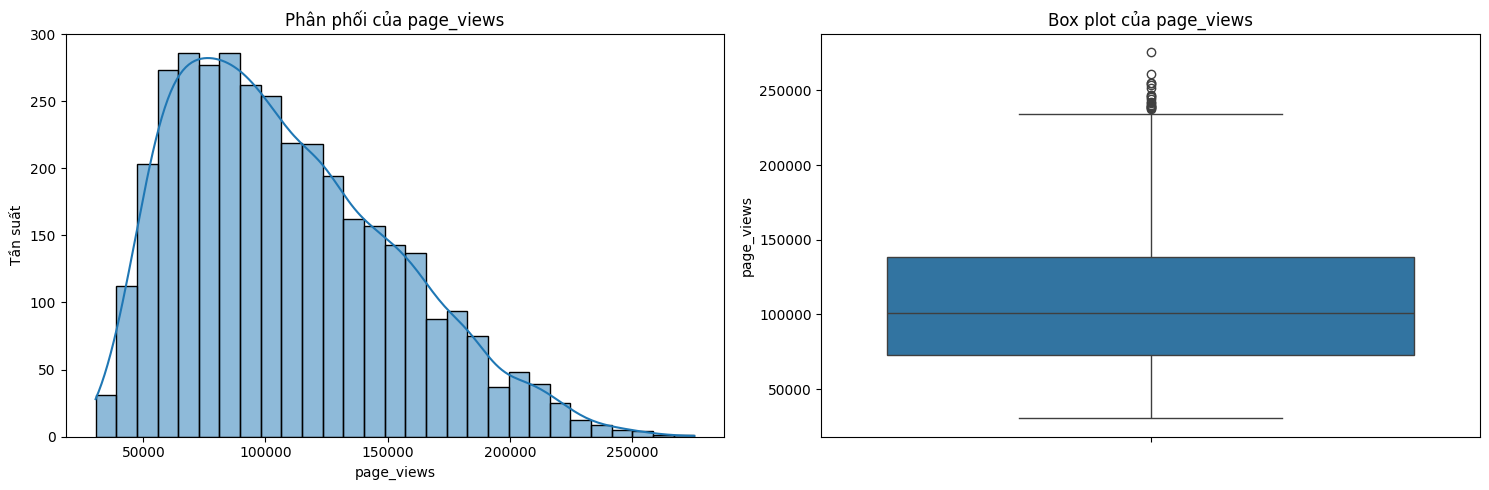

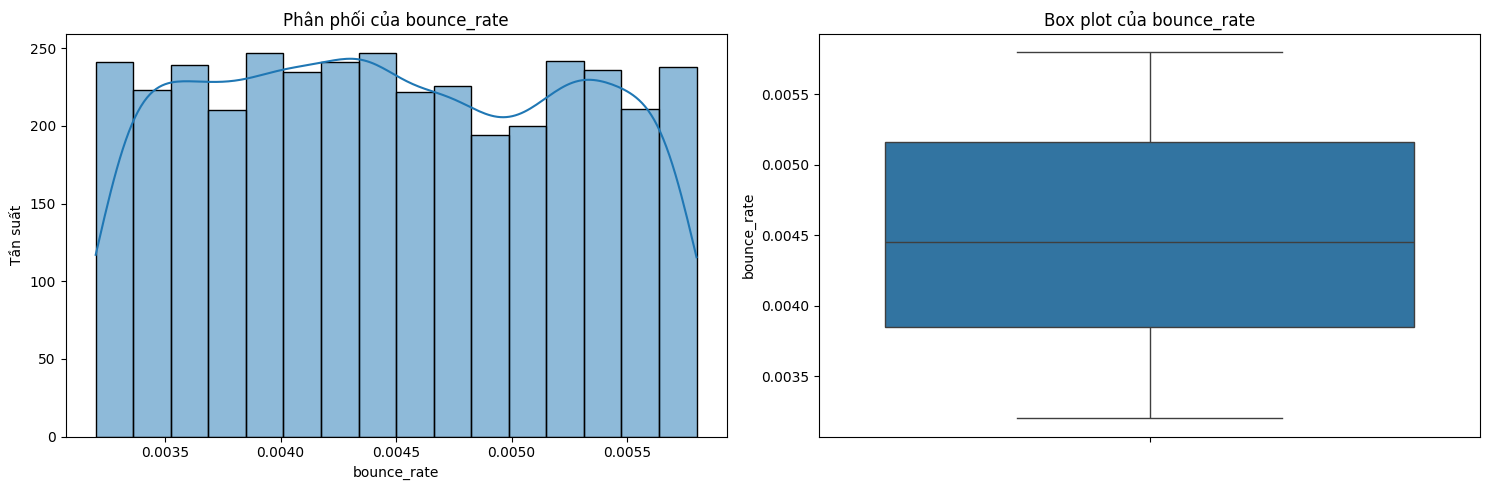

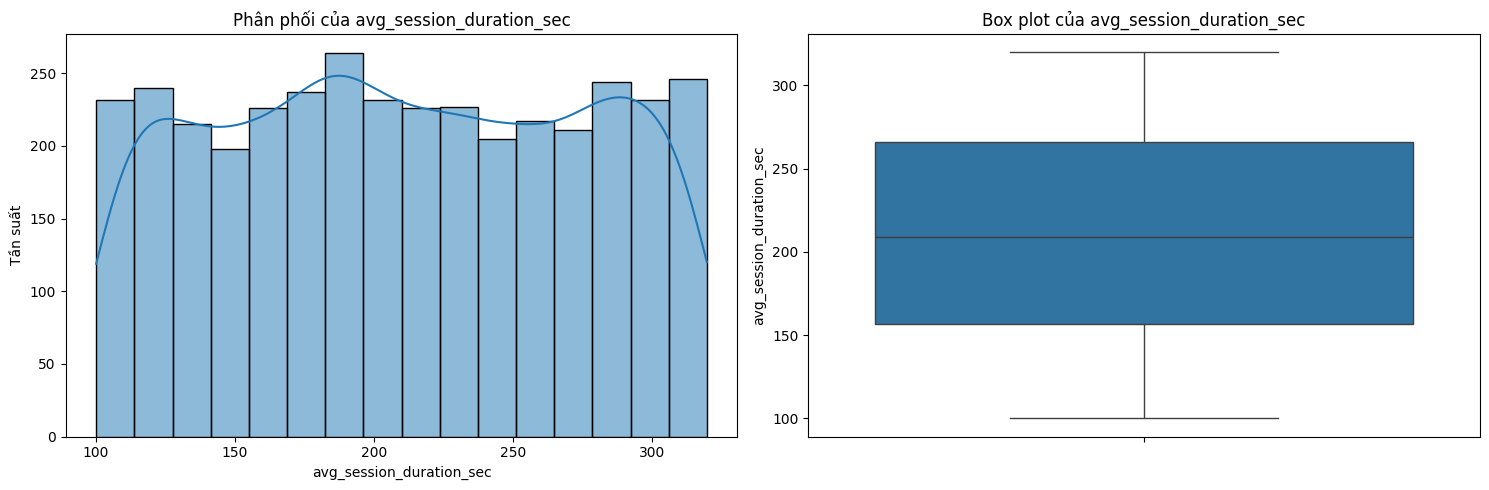

In [80]:
# Lấy danh sách các cột số để phân tích
numerical_cols_web_traffic = df_web_traffic.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols_web_traffic:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_web_traffic[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_web_traffic[col])
    plt.title(f'Box plot của {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Phân tích đơn biến cho các biến định tính

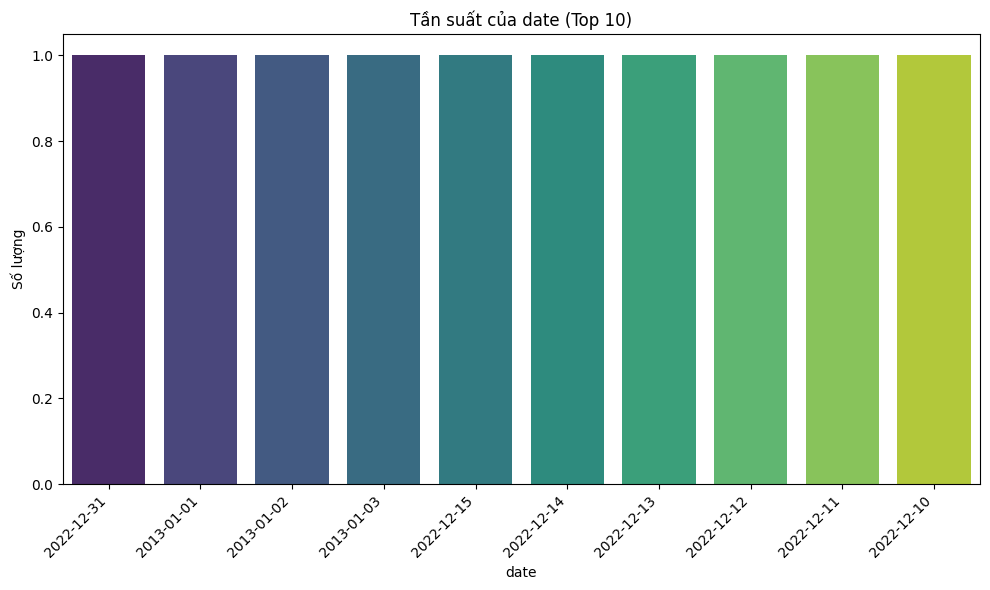

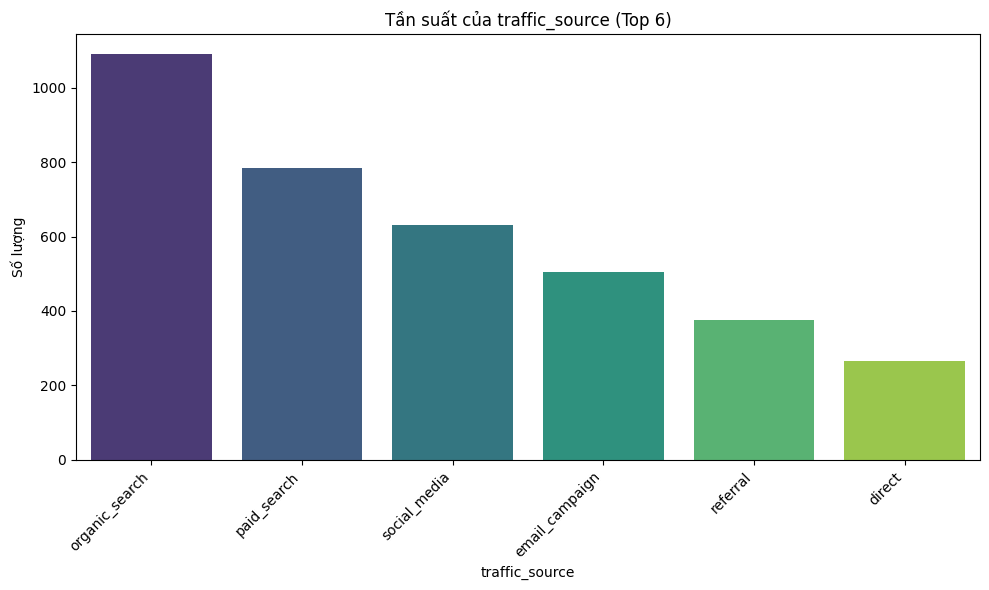

In [81]:
# Lấy danh sách các cột định tính (object)
categorical_cols_web_traffic = df_web_traffic.select_dtypes(include='object').columns.tolist()

for col in categorical_cols_web_traffic:
    plt.figure(figsize=(10, 6))
    plot_data = df_web_traffic[col].value_counts().nlargest(10) # Lấy 10 giá trị hàng đầu
    sns.barplot(x=plot_data.index, y=plot_data.values, hue=plot_data.index, palette='viridis', legend=False)
    plt.title(f'Tần suất của {col} (Top {len(plot_data)})')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 6. Phân tích đa biến (Bivariate/Multivariate Analysis):

### Ma trận tương quan giữa các biến số

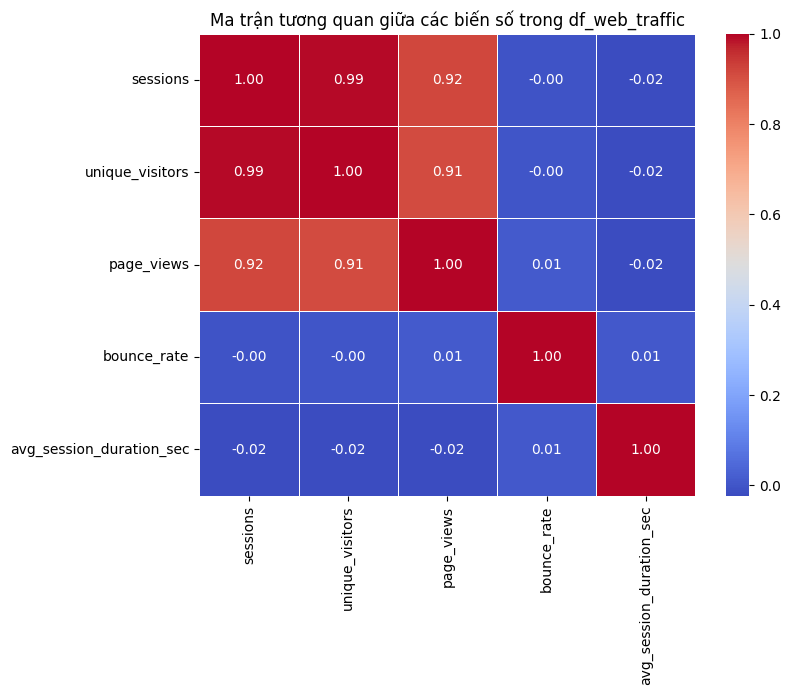

In [82]:
# Chọn các cột số liên quan để tính ma trận tương quan
correlation_cols_web_traffic = df_web_traffic.select_dtypes(include=np.number).columns.tolist()

if len(correlation_cols_web_traffic) > 1:
    corr_matrix_web_traffic = df_web_traffic[correlation_cols_web_traffic].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix_web_traffic, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Ma trận tương quan giữa các biến số trong df_web_traffic')
    plt.show()
else:
    print(f"Chỉ có {len(correlation_cols_web_traffic)} cột số trong df_web_traffic. Không thể tạo ma trận tương quan.")

## 7. Phát hiện và xử lý ngoại lệ (Outlier Detection):

Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_web_traffic:

Cột 'sessions':
  Q1: 17099.25, Q3: 31782.75, IQR: 14683.50
  Ngưỡng dưới (Lower Bound): -4926.00
  Ngưỡng trên (Upper Bound): 53808.00
  Số lượng ngoại lệ: 0


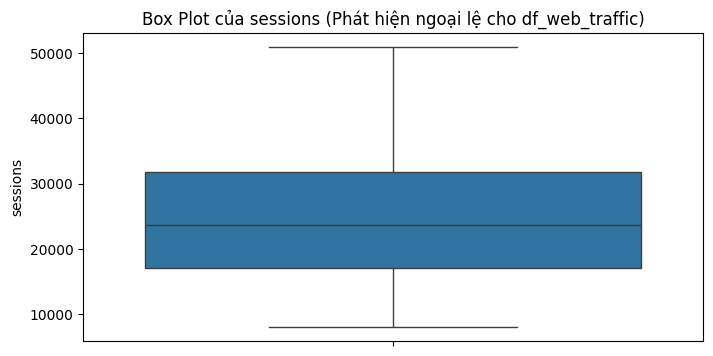


Cột 'unique_visitors':
  Q1: 12915.00, Q3: 24191.75, IQR: 11276.75
  Ngưỡng dưới (Lower Bound): -4000.12
  Ngưỡng trên (Upper Bound): 41106.88
  Số lượng ngoại lệ: 0


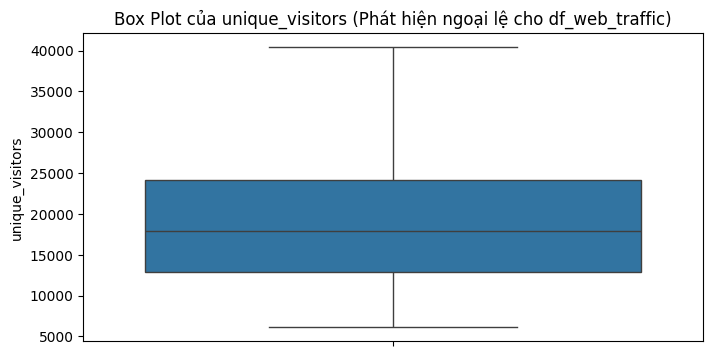


Cột 'page_views':
  Q1: 72982.00, Q3: 138086.00, IQR: 65104.00
  Ngưỡng dưới (Lower Bound): -24674.00
  Ngưỡng trên (Upper Bound): 235742.00
  Số lượng ngoại lệ: 18
  Phần trăm ngoại lệ: 0.49%


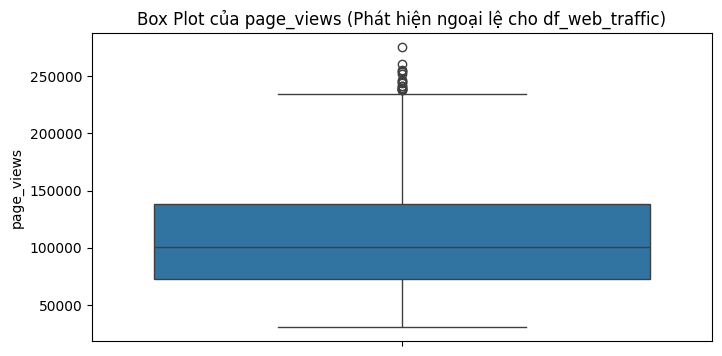


Cột 'bounce_rate':
  Q1: 0.00, Q3: 0.01, IQR: 0.00
  Ngưỡng dưới (Lower Bound): 0.00
  Ngưỡng trên (Upper Bound): 0.01
  Số lượng ngoại lệ: 0


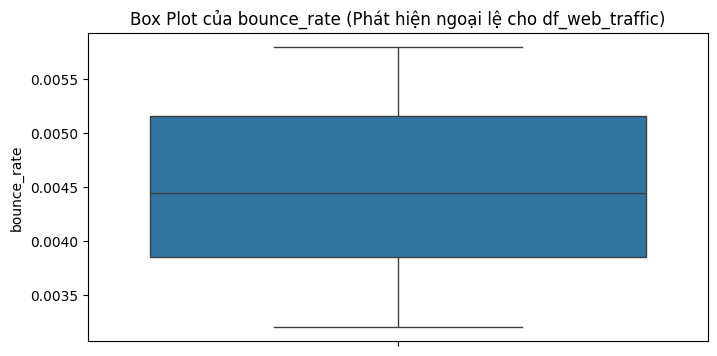


Cột 'avg_session_duration_sec':
  Q1: 156.70, Q3: 266.20, IQR: 109.50
  Ngưỡng dưới (Lower Bound): -7.55
  Ngưỡng trên (Upper Bound): 430.45
  Số lượng ngoại lệ: 0


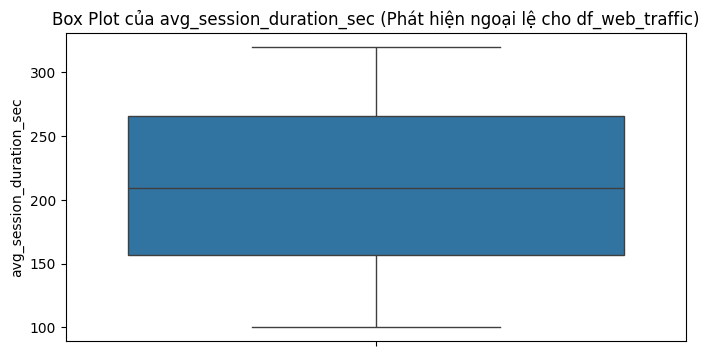

In [83]:
# Lấy danh sách các cột số để phân tích ngoại lệ
numerical_cols_web_traffic_outliers = df_web_traffic.select_dtypes(include=np.number).columns.tolist()

print("Phát hiện ngoại lệ sử dụng phương pháp IQR cho df_web_traffic:")
for col in numerical_cols_web_traffic_outliers:
    Q1 = df_web_traffic[col].quantile(0.25)
    Q3 = df_web_traffic[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_web_traffic[(df_web_traffic[col] < lower_bound) | (df_web_traffic[col] > upper_bound)]

    print(f"\nCột '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
    print(f"  Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
    print(f"  Số lượng ngoại lệ: {len(outliers)}")
    if not outliers.empty:
        print(f"  Phần trăm ngoại lệ: {len(outliers) / len(df_web_traffic) * 100:.2f}%")

    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df_web_traffic[col])
    plt.title(f'Box Plot của {col} (Phát hiện ngoại lệ cho df_web_traffic)')
    plt.ylabel(col)
    plt.show()

## 8. Chuyển đổi kiểu dữ liệu (Data Type Conversion):

In [84]:
# Chuyển đổi cột 'date' sang kiểu datetime
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])

# Kiểm tra lại thông tin tổng quát để xác nhận kiểu dữ liệu đã thay đổi
print('\nThông tin tổng quát của df_web_traffic sau khi chuyển đổi kiểu dữ liệu:')
df_web_traffic.info()


Thông tin tổng quát của df_web_traffic sau khi chuyển đổi kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[ns]
 1   sessions                  3652 non-null   int64         
 2   unique_visitors           3652 non-null   int64         
 3   page_views                3652 non-null   int64         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 199.8+ KB
